# S6E9: what the board paid for eleven submissions

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · [Playground Series S6E9](https://www.kaggle.com/competitions/playground-series-s6e9)*

Eleven submissions on this episode, ten of them carrying two numbers: what cross-validation said, and what
the public board paid. Some of those gains reached the board in full and some arrived as nothing, and the
split runs along one property of the change. Below is the ledger, and where the line falls.

<div align="center">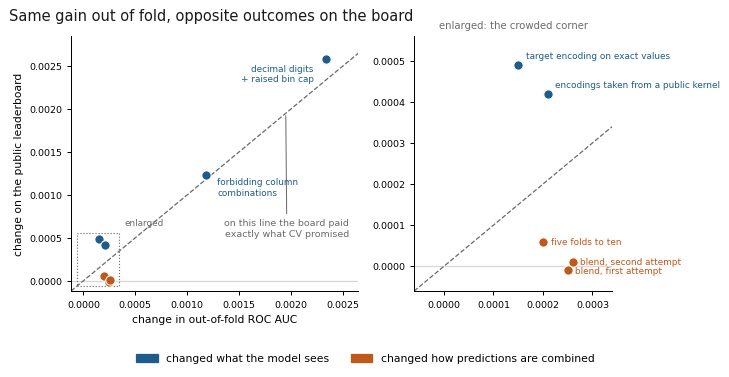</div>

<div align="center"><em>Every blue point lands on the dashed line or above it. The orange ones land on the floor, whatever they promised out of fold.</em></div>

Compared as scores, the two columns look like the same thing: rank correlation 0.976 over those ten,
with the board above the out-of-fold number in eight of them. That is a month of work climbing together, and
it flatters. Compared as **gains**, which is what the table holds and what you actually decide on, the answer
depends on the ruler, so here are both on the identical seven pairs: Pearson 0.970, Spearman 0.357. One row
explains the gap: the largest gain on the page carries the linear number almost by itself, and with the two
largest rows dropped both rulers agree again and both turn negative. Seven rows is not a law, but it is
enough to say the ledger does not behave the way the scores suggest.

Sorted by what was changed, the ledger splits:

| what I changed | out of fold | board |
|---|---|---|
| decimal digits plus a raised bin cap | +0.00234 | +0.00258 |
| forbidding the model to combine columns | +0.00118 | +0.00123 |
| target encoding on each column's exact value | +0.00015 | +0.00049 |
| a block of encodings I took from [Naji's public notebook](https://www.kaggle.com/code/najiama/pure-lgbm-model-cv-0-94606-lb-0-94637) | +0.00021 | +0.00042 |
| five folds to ten | +0.00020 | +0.00006 |
| blending two models, first attempt | +0.00025 | −0.00001 |
| blending two models, second attempt | +0.00026 | +0.00001 |
| averaging three fold splits into the submission | not visible | +0.00000 |

Everything above the line changes **what the model sees**, and the board paid it in full or with interest.
Everything below changes **how the predictions are combined**, and the board paid none of it.

The easy explanation is size, and the ledger rules it out. The smallest out-of-fold gain in the list, +0.00015
from the exact-value encoding, is the one the board multiplied by three, while the blends at +0.00025 and
+0.00026 bought nothing.

§13 gives the mechanism. An out-of-fold row is predicted by one fold model; a test row is predicted by the
average of all of them. Averaging removes more from a noisy construction than a steady one, so a blend whose
whole advantage is variance reduction has already been paid for by the time your file reaches the board.

Before any of these numbers are readable you need to know how small a change can be and still mean something.
A column of random numbers put through the same pipeline moves the out-of-fold score by 0.00015, and by
about 0.0003 once the bin cap is raised, which is the setting the runs above use. The second one moves with
the noise draw, so read it as a size rather than a digit. §7 measures both in your own
session, so you need not take mine on faith. Those are the thresholds for asking "could a meaningless column
have done this". For asking "are these two runs different", the right ruler is paired and about seven times
finer; §13 prints it.

The page also does the ordinary work. It reads the data, builds a cross-validated LightGBM baseline, and writes
a submission whose schema matches `sample_submission`.

### What you get from forking this
- The ledger above in full, in §12 and §13, with every score and the reasoning behind the split.
- A threshold you can point at when you judge your own changes, measured in your own session. That is §7.
- A submission that runs without edits, and an out-of-fold score whose limits §15 spells out.
- One cell, §8, where you write a feature and read a verdict against that threshold.
- Five ideas measured against it in §9, three from this data and two borrowed from the Code tab. The
  three from this data do nothing. Both borrowed ones clear the threshold, and both turn out to be
  asking for the same setting, which §9's second cell shows by running them at two capacities.
- What §10 measures: the model forbidden to combine columns at all. Two lines of parameters that moved
  the board by +0.00123, more than any feature cell on this page.
- Two ways to fool that threshold, in §11. One is the leak everybody warns about. The other is target
  encoding fitted on all of train instead of inside the fold: it passes every check the first one fails,
  costs 47 times the threshold, and the fix is a single `cv=` argument.
- §12 ranks every run of your session in one ladder, each against the floor of its own pipeline, and
  carries the eleven-row ledger above.
- Why the out-of-fold estimate sits below the board for the same file, in §13, with the
  averaging argument behind it and the paired ruler that measures it.
- What the last-day choice between two submissions has cost across every finished Playground Series
  episode, counted from inside the team, closing §13.
- Whether a second model is worth your week, in §14: six of them against my best, then two more built
  at my best's own strength when the obvious objection was that all six were weaker, seven ways to
  combine them under one protocol, and a constructed case that the statistic everyone uses to pick a
  partner cannot see at all.
- Where this data actually comes from and what the generator changed on the way, in §17, including
  what happens when you hand the model the rule that made the data.
- Out-of-fold and test predictions saved as files, on the fold split this series has settled on, so you
  can stack them with someone else's without refitting anything.

### Contents
1. [The data and the task](#1)
2. [The target, and what it does to your metric](#2)
3. [Every column at a glance](#3)
4. [Train against test](#4)
5. [Which columns carry signal on their own](#5)
6. [A baseline you can trust](#6)
7. [The bar: what a meaningless column does to the score](#7)
8. [Test your own idea](#8)
9. [Five ideas, and the two that paid](#9)
10. [How much of this problem is combinations?](#10)
11. [Two ways to fool this instrument, and the one-word fix](#11)
12. [Submission](#12)
13. [What the leaderboard can and cannot tell you, and what the last day costs](#13)
14. [Six second models, and the statistic that ranked them backwards](#14)
15. [Design choices and limitations](#15)
16. [Where to take it next](#16)
17. [Where this data actually comes from](#17)

*Written across the month and finished in its second half. Every section here runs; the ledger above is complete through my eleventh submission.*

In [ ]:
import os, glob, random, textwrap, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); os.environ["PYTHONHASHSEED"] = str(s)
seed_everything()

# Okabe-Ito palette: safe for the common forms of colour blindness
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
INK, GREY, PALE = "#14212B", "#6B7785", "#C9CFD6"     # Okabe-Ito has no neutral; these are it
DEEP, DGOLD = "#31708F", "#8A6400"                    # the same hues, dark enough to be text

# Kaggle shows the body at about 730 px and does NOT stretch a figure, so a 648 px PNG just sits
# in a 730 px column. Pin the output to the column width and the same 11pt renders 23% larger:
# type on screen is pt x (shown px) / (width in inches x 72), so the narrower figure wins.
FIGW = 6.6
plt.rcParams.update({
    "figure.dpi": 730 / FIGW, "savefig.dpi": 730 / FIGW, "figure.figsize": (FIGW, 3.0),
    "figure.facecolor": "white", "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 10.5,
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "sans-serif"],
    "axes.grid": True, "grid.alpha": 0.25, "grid.color": PALE, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": PALE,
    "xtick.color": GREY, "ytick.color": GREY, "axes.labelcolor": GREY, "text.color": INK,
    "legend.frameon": False})


def head(fig, finding, setup=None, left=0.012):
    # CALL THIS LAST, after any tight_layout: it reserves the strip the title sits in, and a
    # later tight_layout would give that strip back to the axes and run them into the text.
    # Title block on the FIGURE, flush left. ax.set_title centres over the axes, and long row
    # labels shove it sideways and cap its length, which is why a title could not state a finding
    # before. Off the axes it gets the full width.
    h = fig.get_figheight()
    finding = "\n".join(textwrap.wrap(finding, 58))
    top = 0.10 + 0.25 * (finding.count("\n") + 1)
    if setup:
        setup = "\n".join(textwrap.wrap(setup, 84))
        top += 0.10 + 0.19 * (setup.count("\n") + 1)
        fig.text(left, 1 - (0.15 + 0.25 * (finding.count("\n") + 1)) / h, setup, ha="left",
                 va="top", fontsize=9.8, color=GREY, linespacing=1.35)
    fig.text(left, 1 - 0.13 / h, finding, ha="left", va="top", fontsize=12.5, weight="bold",
             color=INK, linespacing=1.25)
    fig.tight_layout(rect=[0, 0, 1, 1 - top / h])


def at(ax, x, y, s, color=INK, dx=7, dy=0, size=10, weight="normal", ha="left"):
    # Label the series where the series is. A legend is a lookup table: the eye leaves the mark,
    # finds the key, decodes, comes back.
    ax.annotate(s, (x, y), textcoords="offset points", xytext=(dx, dy), color=color,
                fontsize=size, weight=weight, va="center", ha=ha, clip_on=False, zorder=6)

def takeaway(*lines):
    # one consistent shape for every conclusion, wrapped to the width Kaggle renders
    print()
    for l in lines:
        for part in textwrap.wrap(l, 83) or [""]:
            print("|  " + part)

def find_data(slug=""):
    # the competition's own folder first: an attached extra dataset may also ship a train.csv
    for p in [f"/kaggle/input/{slug}", f"/kaggle/input/competitions/{slug}",
              os.environ.get("LOCAL_DATA", ""), "data", "../data"]:
        if p and os.path.exists(os.path.join(p, "train.csv")):
            return p
    hits = sorted(glob.glob("/kaggle/input/**/train.csv", recursive=True))
    if hits:
        print("NOTE: falling back to", hits[0], "- check this is the competition's own train.csv")
        return os.path.dirname(hits[0])
    raise FileNotFoundError("train.csv not found. /kaggle/input holds: " + str(glob.glob("/kaggle/input/*")))

<a id="1"></a>
## 1. The data and the task

Four settings at the top of the next cell decide everything downstream. `COMP_SLUG` is the tail of the
competition's URL, and it tells the loader which input folder is the competition's own rather than an attached
dataset that happens to ship a `train.csv` too. `METRIC` is on the Evaluation tab. `TASK` is an override for the
case where the guess below gets it wrong.

`FAST` is the one to reach for while you are working. It cuts the rows, the folds and the boosting rounds, and
it cuts them for every run on the page, including the noise draws that set the bar. So a fast session still
answers "did my idea beat noise" correctly; what it cannot do is give you a number comparable to a full run, or
a submission worth uploading. The notebook says so in every place it matters.

In [ ]:
# ================= the settings you are meant to touch =================
COMP_SLUG = "playground-series-s6e9"    # the tail of the competition URL
METRIC    = "roc_auc"                    # from the Evaluation page
TASK      = "binary"                     # binary / multiclass / regression
FAST      = False                     # True while you edit: fewer rows and
                                      # folds, far quicker, not comparable
# =======================================================================

In [ ]:
DATA  = find_data(COMP_SLUG)
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test  = pd.read_csv(os.path.join(DATA, "test.csv"))
samp  = pd.read_csv(os.path.join(DATA, "sample_submission.csv"))

id_col   = samp.columns[0]
sub_cols = [c for c in samp.columns if c != id_col]
assert id_col in test.columns, (f"sample_submission's id column '{id_col}' is not in test "
                                f"{list(test.columns[:4])} - name it by hand")

only_in_train = [c for c in train.columns if c not in test.columns]
target = only_in_train[0] if len(only_in_train) == 1 else sub_cols[0]
assert target in train.columns, (f"could not identify the target: train holds {only_in_train} that test "
                                 f"lacks, and '{target}' is not one of them - name it by hand")

features = [c for c in test.columns if c not in (id_col, target)]   # never the target, never the id

y_raw     = train[target]
n_classes = y_raw.nunique()
if TASK != "auto":
    task = TASK
elif n_classes == 2:
    task = "binary"
elif pd.api.types.is_numeric_dtype(y_raw) and (pd.api.types.is_float_dtype(y_raw) or n_classes > 20):
    task = "regression"
else:
    task = "multiclass"

cat_feats = [c for c in features
             if not pd.api.types.is_numeric_dtype(train[c]) or train[c].dtype == bool]
num_feats = [c for c in features if c not in cat_feats]
lowcard   = [c for c in num_feats if train[c].nunique() <= 15]   # numeric, but with few distinct values

metric = METRIC if METRIC != "auto" else \
    {"regression": "rmse", "binary": "roc_auc", "multiclass": "accuracy"}[task]
SUB_FORMAT = "per_class" if len(sub_cols) > 1 else "single"

KNOWN_METRICS = ("rmse", "rmsle", "mae", "roc_auc", "log_loss", "accuracy", "balanced_accuracy")
if metric not in KNOWN_METRICS:
    raise ValueError(f"METRIC '{metric}' is not implemented here. Known: {KNOWN_METRICS}. "
                     "Add it to score() in section 6 before going further -- otherwise every number "
                     "below would silently be a different metric.")

print(f"target        : {target}")
print(f"task          : {task}" + ("   [guessed]" if TASK == "auto" else "   [set by hand]")
      + f"   ({n_classes:,} distinct target values, dtype {y_raw.dtype})")
print(f"metric        : {metric}" + ("   [guessed]" if METRIC == "auto" else "   [set by hand]"))
print(f"submission    : {SUB_FORMAT}   ({len(sub_cols)} column(s) besides '{id_col}')")
print(f"features      : {len(features)}  =  {len(num_feats)} numeric + {len(cat_feats)} categorical")
if lowcard:
    for i, part in enumerate(textwrap.wrap("numeric but low-cardinality: " + ", ".join(lowcard), 70)):
        print(("                " if i == 0 else "                  ") + part)
print(f"train / test  : {len(train):,} / {len(test):,} rows")
if TASK == "auto" and task == "multiclass" and pd.api.types.is_integer_dtype(y_raw):
    takeaway(f"'{target}' is a whole-number column with {n_classes} distinct values, so it was read as"
             f" {task}.",
             "If this episode is judged by RMSE on a count or a rating, that guess is wrong:"
             " set TASK above by hand.")
train.head()

The target is the column `train` has and `test` does not. When `TASK` is `auto` the task is guessed from that column's dtype and
how many distinct values it holds, and the printout says whether that happened or whether you set it, and one case breaks that guess: a whole-number target with few levels, say a
rating or a count, reads as a class problem even when the episode is judged by RMSE. If the printout above
disagrees with the Evaluation page, set `TASK` and `METRIC` by hand and re-run. Everything below follows what
that cell prints.

The cell also sorts columns into numeric and categorical by dtype, not by how many distinct values they happen
to have. An integer column with twelve levels is still numeric, and that choice changes both the chart it gets
in §4 and how §5 estimates its signal.

<a id="2"></a>
## 2. The target, and what it does to your metric

The shape of the target decides how you read every score below it. Imbalance decides whether accuracy means
anything at all; skew decides whether the model is better off fitted in log space.

In [ ]:
fig, ax = plt.subplots(figsize=(FIGW, 3.2))
if task == "regression":
    ax.hist(train[target], bins=60, color=PALETTE[0], alpha=0.85)
    ax.set_xlabel(target); ax.set_ylabel("rows")
    ax.set_title(f"Target '{target}': skew {train[target].skew():.2f}")
    plt.tight_layout(); plt.show()
    print(train[target].describe().round(3).to_string())
    sk = train[target].skew()
    takeaway(f"Skew is {sk:.2f}.",
             "A tail this heavy usually rewards modelling in log space. Worth testing in section 8."
             if abs(sk) > 1 else
             "Close enough to symmetric that a transform is unlikely to be the lever here.")
else:
    vc = train[target].value_counts()
    ax.bar([str(c) for c in vc.index], vc.values, color=PALETTE[:len(vc)])
    for i, v in enumerate(vc.values):
        ax.text(i, v, f"{v/len(train)*100:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("rows, thousands"); ax.set_xlabel(target); ax.margins(y=0.15)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}")
    plt.tight_layout()
    head(fig, f"{vc.index[0]} takes {vc.max()/len(train):.1%} of the rows",
         f"{len(vc)} classes, the largest {vc.max()/vc.min():.1f} times the smallest. "
         f"{metric} is what decides.")
    plt.show()
    rarest = vc.min() / len(train)
    # what an imbalance costs you depends on the metric, so the advice branches on it
    _ranks = metric in ("roc_auc", "log_loss", "map", "mean_average_precision")
    takeaway(f"The rarest class is {rarest:.1%} of the rows.",
             (f"{metric} reads the order of your predictions, not a threshold, so this imbalance"
              f" costs you nothing directly. Where it shows up is variance: the rare class carries"
              f" {vc.min():,} rows, and every fold score rests on a fifth of those."
              if _ranks else
              f"Plain accuracy means little here: always answering '{vc.index[0]}' already scores"
              f" {vc.max()/len(train):.1%}. {metric} is the number that decides, and §16 says where"
              f" the threshold for it belongs."
              if rarest < 0.10 else
              f"Balanced enough that a threshold at 0.5 is not obviously wrong, though {metric}"
              f" is what decides."))

<a id="3"></a>
## 3. Every column at a glance

One table with what is worth knowing before you model: the type of each column, how many distinct values it
takes, and how lopsided it is. A column where almost every row shares one value gives a tree very little to
split on. A numeric column with six distinct values can be a category wearing a number's clothes, though
whether the model cares is a measurement rather than a rule, and §9 makes it.

If this episode has missing values the table shows them too, along with a check on whether the *fact* of a gap
carries signal. LightGBM learns a direction for NaN by itself, so filling gaps is not urgent; what it cannot see
is a pattern *across* columns, which is what §8 tests when there are gaps to count.

In [ ]:
rows = []
for c in features:
    vc = train[c].value_counts(normalize=True, dropna=True)
    rows.append((c, "categorical" if c in cat_feats else "numeric", f"{train[c].nunique():,}",
                 f"{train[c].isna().mean()*100:.2f}%", str(vc.index[0])[:18], f"{vc.iloc[0]:.1%}"))
dic = pd.DataFrame(rows, columns=["column", "type", "distinct", "missing", "most common", "its share"])
print(dic.to_string(index=False))

lop = dic.assign(sh=[float(x.strip("%")) for x in dic["its share"]]).sort_values("sh", ascending=False)
takeaway(f"Most lopsided column: {lop.iloc[0]['column']}, one value covers"
         f" {lop.iloc[0]['its share']} of the rows.",
         f"Numeric but low-cardinality: {', '.join(lowcard) if lowcard else 'none'}."
         + (" Those behave like categories, worth trying as such." if lowcard else ""))

miss = (train[features].isna().mean() * 100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)

if not len(miss):
    print("\nNo missing values anywhere in train, so there is no gap pattern to build on.")
else:
    fig, ax = plt.subplots(figsize=(FIGW, max(1.8, 0.32 * len(miss))))
    ax.barh(miss.index, miss.values, color=PALETTE[1]); ax.invert_yaxis()
    ax.set_xlabel("% of rows missing"); ax.set_title("Missing values by column (train)")
    plt.tight_layout(); plt.show()

    if task == "regression":
        rows = [(c, f"{train[c].isna().sum():,}", f"{train.loc[train[c].isna(), target].mean():.4f}",
                 f"{train.loc[train[c].notna(), target].mean():.4f}") for c in miss.index]
        tbl = pd.DataFrame(rows, columns=["column", "rows missing", "mean when missing", "mean when present"])
    else:
        top = train[target].mode()[0]
        rows = [(c, f"{train[c].isna().sum():,}",
                 f"{(train.loc[train[c].isna(), target] == top).mean():.4f}",
                 f"{(train.loc[train[c].notna(), target] == top).mean():.4f}") for c in miss.index]
        tbl = pd.DataFrame(rows, columns=["column", "rows missing",
                                          f"P({target}={top}) when missing", "when present"])
    print(tbl.to_string(index=False))
    gapv = (tbl.iloc[:, 2].astype(float) - tbl.iloc[:, 3].astype(float)).abs()
    w = int(gapv.idxmax())
    takeaway(f"Widest gap: '{tbl.iloc[w, 0]}', {gapv[w]:.4f} across {tbl.iloc[w, 1]} missing rows.",
             "One number with no interval around it, so read it as a place to look.",
             "Section 8 is where an idea actually gets tested.")

<a id="4"></a>
## 4. Train against test

Playground data is generated once and then split, so the two halves usually agree closely. In the episode where
they do not, validation quietly lies for everyone who skipped this, and every out-of-fold number below becomes a
measure of the wrong population.

Looking at histograms answers this badly. The question is whether anything at all separates the two files, and a
model answers it directly: label every training row 0 and every test row 1, then try to tell them apart out of
fold. If that model scores 0.5 it cannot, which is what you want. The further above 0.5 it goes, the more the
two halves differ, and the model will name the columns doing the separating.

In [ ]:
from sklearn.model_selection import StratifiedKFold as _SKF
from sklearn.metrics import roc_auc_score as _auc
import lightgbm as _lgb

# label train 0 and test 1, then try to tell them apart. 0.5 means the two files are the same
# population, which is the answer you want. A subsample keeps this to a few seconds.
_n = min(60000, len(train), len(test))
_rng = np.random.default_rng(SEED)
_A = pd.concat([train[features].iloc[_rng.choice(len(train), _n, replace=False)],
                test[features].iloc[_rng.choice(len(test), _n, replace=False)]], ignore_index=True)
for _c in _A.columns:
    if not pd.api.types.is_numeric_dtype(_A[_c]):
        _A[_c] = pd.Categorical(_A[_c].astype(str))
_y = np.r_[np.zeros(_n), np.ones(_n)]
_advp = dict(objective="binary", learning_rate=0.1, num_leaves=31, verbose=-1,
             min_child_samples=50, num_threads=os.cpu_count())
_oof, _imp = np.zeros(len(_A)), np.zeros(len(features))
for _tr, _va in _SKF(3, shuffle=True, random_state=SEED).split(_A, _y):
    _m = _lgb.train(_advp,
                    _lgb.Dataset(_A.iloc[_tr], _y[_tr]), num_boost_round=200,
                    valid_sets=[_lgb.Dataset(_A.iloc[_va], _y[_va])],
                    callbacks=[_lgb.early_stopping(25, verbose=False)])
    _oof[_va] = _m.predict(_A.iloc[_va], num_iteration=_m.best_iteration)
    _imp += _m.feature_importance("gain") / 3
adv = _auc(_y, _oof)
_top = pd.Series(_imp, index=features).sort_values(ascending=False)

# The control: train cut against ITSELF. Two halves of one file are the same population by
# construction, so whatever this prints is what "no difference at all" looks like on this
# instrument. Without it, 0.499 and 0.501 are just numbers with no scale attached.
_h = _rng.choice(len(train), min(2 * _n, len(train)), replace=False)
_C = train[features].iloc[_h].reset_index(drop=True)
for _c in _C.columns:
    if not pd.api.types.is_numeric_dtype(_C[_c]):
        _C[_c] = pd.Categorical(_C[_c].astype(str))
_yc = np.r_[np.zeros(len(_C) // 2), np.ones(len(_C) - len(_C) // 2)]
_oofc = np.zeros(len(_C))
for _tr, _va in _SKF(3, shuffle=True, random_state=SEED).split(_C, _yc):
    _mc = _lgb.train(_advp, _lgb.Dataset(_C.iloc[_tr], _yc[_tr]), num_boost_round=200,
                     valid_sets=[_lgb.Dataset(_C.iloc[_va], _yc[_va])],
                     callbacks=[_lgb.early_stopping(25, verbose=False)])
    _oofc[_va] = _mc.predict(_C.iloc[_va], num_iteration=_mc.best_iteration)
adv0 = _auc(_yc, _oofc)

print(f"telling train from test, out of fold, on {_n:,} rows of each: AUC = {adv:.5f}")
print(f"the same test on train against ITSELF (identical by construction):  {adv0:.5f}")
print("the columns it leaned on most: "
      + ", ".join(f"{k} {100 * v / max(_imp.sum(), 1e-9):.0f}%" for k, v in _top.head(3).items()))
takeaway(f"Train against test scores {adv:.5f}; two halves of train against each other score "
         f"{adv0:.5f}. "
         + ("The two files are as alike as one file is to itself, so an out-of-fold score here "
            "is measuring the population you will be scored on."
            if abs(adv - 0.5) < abs(adv0 - 0.5) + 0.02 else
            "Test sits further from train than train sits from itself, so trust the out-of-fold "
            "numbers below less, and look at the columns named above before you build on them."),
         "Now the blind spot, because it is wide. A group of rows that a model could pick out "
         "perfectly moves this number by exactly half that group's share. A perfectly separable "
         "0.24% of test would read 0.5012, which is inside the noise you see above and would be "
         "reported as no difference. So this says no LARGE shift, never no shift.")

The figure below is the follow-up rather than the check. The claim is about a *difference*, so it draws the
difference. Each dot is one bin of one column, placed by how far test sits from train there, measured in standard
errors of that gap. A shared ruler is the only way bins of different sizes go on one axis, and it is why every
column fits. The band is a fixed plus or minus two. Chance alone puts about one bin in twenty outside it, and the
title checks its own count against that number. The two lines under the figure are exact: which categories turn
up in test that train never saw, and the column whose missing rate differs most.

In [ ]:
DR_BINS, DR_MAXLEV = 12, 30
dr_rows = []
for c in features:
    a, b = train[c], test[c]
    if c in cat_feats:
        # a wide categorical would put hundreds of dots on one line: keep the commonest levels and
        # pool the rest into one bin, which is still an exact share-against-share comparison
        keep = list(pd.concat([a, b]).dropna().value_counts().index[:DR_MAXLEV])
        ka = a.where(a.isin(keep), "other").value_counts()
        kb = b.where(b.isin(keep), "other").value_counts()
        lv = sorted(set(ka.index) | set(kb.index), key=str)
        ka = ka.reindex(lv).fillna(0).to_numpy(); kb = kb.reindex(lv).fillna(0).to_numpy()
    else:
        v = pd.concat([a, b]).dropna()
        edges = np.unique(np.quantile(v, np.linspace(0, 1, DR_BINS + 1))) if len(v) else np.array([])
        if len(edges) < 2:                       # a constant column has no bins to compare
            continue
        ka = np.histogram(a.dropna(), bins=edges)[0].astype(float)
        kb = np.histogram(b.dropna(), bins=edges)[0].astype(float)
    na, nb = ka.sum(), kb.sum()
    if na == 0 or nb == 0:
        continue
    pa, pb = ka / na, kb / nb
    pooled = (ka + kb) / (na + nb)
    se = np.sqrt(pooled * (1 - pooled) * (1 / na + 1 / nb))
    z = np.divide(pb - pa, se, out=np.zeros_like(pa), where=se > 0)
    for dpp, zz in zip(100 * (pb - pa), z):
        dr_rows.append((c, dpp, zz))

DR = pd.DataFrame(dr_rows, columns=["col", "dpp", "z"])
if len(DR):
    dr_all = len(DR); dr_far = int((DR.z.abs() > 2).sum())
    dr_exp = 0.0455 * dr_all          # what a plain +/-2 band lets through when nothing is wrong
    dr_worst = DR.loc[DR.z.abs().idxmax()]
    dr_order = sorted(DR.col.unique(), key=lambda c: DR.loc[DR.col == c, "z"].abs().max())

    fig, ax = plt.subplots(figsize=(FIGW, max(2.4, 0.30 * len(dr_order) + 1.0)))
    ax.axvspan(-2, 2, color=PALETTE[4], alpha=0.16, zorder=0, lw=0)
    ax.axvline(0, color=INK, lw=1, zorder=1)
    for i, c in enumerate(dr_order):
        g = DR[DR.col == c].sort_values("z"); n = len(g)
        y = i + (np.arange(n) % 3 - 1) * (0.10 if n > 4 else 0.0)
        far = g.z.abs().to_numpy() > 2
        ax.scatter(g.z[~far], y[~far], s=24, color=PALETTE[0], alpha=0.8, lw=0, zorder=3)
        ax.scatter(g.z[far], y[far], s=30, color=PALETTE[5], lw=0, zorder=4)
    lim = max(2.7, DR.z.abs().max() * 1.18)
    ax.set_xlim(-lim, lim); ax.set_ylim(-0.75, len(dr_order) - 0.15)
    ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_yticks(range(len(dr_order)))
    ax.set_yticklabels(dr_order, fontsize=9)
    ax.set_xlabel("test share minus train share, in standard errors of that difference")
    ax.grid(axis="y", alpha=0.10)
    plt.tight_layout()
    # the count can come out either way, and the wording follows it rather than the reverse
    head(fig, (f"{dr_all - dr_far} of {dr_all} bins sit inside sampling noise" if dr_far <= 2 * dr_exp
               else f"{dr_far} of {dr_all} bins differ by more than chance explains"),
         f"One dot per bin of one column, all {len(dr_order)} of them. Chance alone would put about "
         f"{dr_exp:.0f} outside the band; the widest gap here is {abs(dr_worst.dpp):.2f} points of a "
         f"percent, on {dr_worst.col}. Telling the two files apart scores {adv:.5f}.")
    plt.show()

unseen = {c: sorted(set(test[c].dropna().unique()) - set(train[c].dropna().unique()))[:5]
          for c in cat_feats}
unseen = {c: v for c, v in unseen.items() if v}
miss_rate = pd.DataFrame({"train %": (train[features].isna().mean() * 100).round(2),
                          "test %":  (test[features].isna().mean() * 100).round(2)})
miss_rate["gap"] = (miss_rate["train %"] - miss_rate["test %"]).abs()
worst = miss_rate.sort_values("gap", ascending=False).head(3)

takeaway(("Categories present in test but never in train: " + ", ".join(f"{c}={v}" for c, v in unseen.items())
          if unseen else "No category appears in test that is absent from train."),
         (f"Largest train/test difference in missing rate: {worst.index[0]} "
          f"({worst['train %'].iloc[0]:.2f}% against {worst['test %'].iloc[0]:.2f}%)."
          if miss_rate["gap"].max() > 0 else "Missing rates are identical in train and test."))

<a id="5"></a>
## 5. Which columns carry signal on their own

Mutual information asks what each column tells you about the target on its own. Read it as a reading order and
not as a shortlist, because it misleads in both directions. A column can rank high while adding nothing once the
model already has its neighbour, and a column can rank at zero and still be decisive **in combination** with
another, since this never looks at pairs. §10 measures what combinations are worth here, and the answer is not
what you would guess from this chart.

One detail that changes how you read it: missing values are filled with a sentinel first, so part of a column's
score can come from where it is missing rather than from its values.

In [ ]:
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

Xmi = train[features].copy()
for c in cat_feats:
    Xmi[c] = Xmi[c].astype("category").cat.codes
Xmi = Xmi.fillna(-999)

mi_fn = mutual_info_regression if task == "regression" else mutual_info_classif
mi = pd.Series(mi_fn(Xmi, train[target], discrete_features=[c in cat_feats for c in features],
                     random_state=SEED), index=features).sort_values()

fig, ax = plt.subplots(figsize=(FIGW, max(2.2, 0.30 * len(mi))))
ax.barh(mi.index, mi.values, color=[PALETTE[3] if f in cat_feats else PALETTE[0] for f in mi.index])
# the note lives in the axis label: as a floating annotation it landed on the legend
ax.set_xlabel("mutual information with the target, in nats", fontsize=10)
# a zero-length bar is indistinguishable from a missing one, so every row gets a visible stub
for i, v in enumerate(mi.values):
    if v <= mi.max() * 0.004:
        ax.plot(mi.max() * 0.004, i, "|", color="0.45", ms=9)
if cat_feats:      # a legend, not a colour promise in the title: a zero-length bar is invisible
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=PALETTE[0], label="numeric"), Patch(color=PALETTE[3], label="categorical")],
              fontsize=9, loc="lower right")
plt.tight_layout()
_top2 = mi.sort_values(ascending=False)
head(fig, f"{_top2.index[0]} carries {_top2.iloc[0] / max(_top2.iloc[1], 1e-9):.1f} times what the "
          f"next column does on its own",
     "Each column against the target by itself. A tick at the axis is a measured zero, not a missing "
     "value, and this measure never looks at pairs.")
plt.show()

top3 = list(mi.sort_values(ascending=False).index[:3])
zeros = list(mi[mi <= 1e-4].index)
takeaway(f"Strongest on their own: {', '.join(top3)}.",
         (f"At or near zero: {', '.join(zeros)}."
          "  A pair is untested rather than dead, because this measure never looks at pairs,"
          "  but read section 10 for what a combination is worth on this data first." if zeros else
          "No column sits at zero, so nothing here is obviously dead weight."))

<a id="6"></a>
## 6. A baseline you can trust

LightGBM on a K-fold split, stratified when the target is a class and every class has at least as many rows as
there are folds, plain K-fold otherwise. Scored on out-of-fold predictions, so no row is in the training set of
the model that grades it, with the caveat §15 spells out. Categorical columns go in natively, and the only
mapping applied to them is a label code shared by train and test, so nothing derived from the target is
computed outside the fold.

The parameters are fixed sensible values that were not tuned for this episode. That is deliberate: an untuned
floor is the honest thing to measure improvements against. `FAST` from §1 lands here, setting the fold count,
the round cap and the size of the row sample that every run shares.

The whole loop lives in one function, `run_cv()`, which every section after it calls again with different inputs. Its cell
is folded to keep the page readable; open it here, or fork the notebook and read it in the editor. Three cells are left open on the page: the settings in §1, the feature
cell in §8, and the single line in §12 that picks what gets submitted. Those are the ones you are meant to
change.

In [ ]:
import time
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import (roc_auc_score, accuracy_score, balanced_accuracy_score,
                             mean_squared_error, log_loss)
import lightgbm as lgb

if task == "regression":
    y = train[target].to_numpy(dtype=float); n_out = 1; le = None
    objective = dict(objective="regression", metric="rmse")
else:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder(); y = le.fit_transform(train[target]); n_out = len(le.classes_)
    objective = (dict(objective="binary") if task == "binary"
                 else dict(objective="multiclass", num_class=n_out))

# FAST changes three things at once, and it changes them for EVERY run in this notebook, the noise
# draws included. That is the point: comparisons inside one setting stay honest, and only the
# absolute numbers move. The row subsample is drawn once here and reused, so every run sees the
# same rows.
FOLDS     = 3 if FAST else 5
ROUNDS    = 400 if FAST else 1500
FAST_ROWS = 150_000
ROWS = (np.random.default_rng(SEED).choice(len(train), min(FAST_ROWS, len(train)), replace=False)
        if FAST else np.arange(len(train)))
TR, Y = train.iloc[ROWS].reset_index(drop=True), y[ROWS]
if FAST:
    print(f"FAST is on: {len(TR):,} of {len(train):,} rows, {FOLDS} folds, {ROUNDS} rounds.")
    print("Numbers below are NOT comparable to a full run. They are comparable to each other,")
    print("because the bar in section 7 is measured under exactly the same setting.")

PARAMS = dict(**objective, learning_rate=0.05, num_leaves=63, feature_fraction=0.8,
              bagging_fraction=0.8, bagging_freq=1, min_child_samples=50,
              verbose=-1, num_threads=os.cpu_count())
LOWER_IS_BETTER = metric in ("rmse", "rmsle", "mae", "log_loss")

def score(y_true, p):
    # p: probabilities for classification, values for regression
    if metric == "rmse":              return mean_squared_error(y_true, p) ** 0.5
    if metric == "rmsle":             return mean_squared_error(np.log1p(np.clip(y_true, 0, None)),
                                                                np.log1p(np.clip(p, 0, None))) ** 0.5
    if metric == "mae":               return float(np.abs(y_true - p).mean())
    if metric == "roc_auc":
        if p.ndim > 1 and p.shape[1] > 2:
            return roc_auc_score(y_true, p, multi_class="ovr", average="macro",
                                 labels=list(range(n_out)))
        return roc_auc_score(y_true, p[:, 1] if p.ndim > 1 else p)
    if metric == "log_loss":
        pp = p if p.ndim > 1 else np.column_stack([1 - p, p])
        return log_loss(y_true, pp, labels=list(range(n_out)))
    hard = p.argmax(1) if p.ndim > 1 else (p >= 0.5).astype(int)
    if metric == "balanced_accuracy": return balanced_accuracy_score(y_true, hard)
    return accuracy_score(y_true, hard)

def run_cv(make=None, label="baseline", n_folds=None, rounds=None, seed=None, log=True,
           fold_make=None, extra=None, params=None):
    n_folds = FOLDS if n_folds is None else n_folds
    rounds  = ROUNDS if rounds is None else rounds
    seed = SEED if seed is None else seed        # read at call time, so changing SEED moves everything
    # extra: a frame of labelled rows to TRAIN on and never grade. They ride at the end, join the
    # training part of every fold, and take no part in the split or the score.
    # make(df) -> df runs ONCE on train and ONCE on test, before the folds are cut: row-wise only.
    # fold_make(Xtr, ytr) -> put(df) -> df is the other hook. It is called inside every fold with
    # that fold's TRAINING rows only, and the returned `put` is applied to train, validation and
    # test. Anything fitted on the target belongs here, not in make(). Section 11 shows why.
    # params overrides PARAMS for this run only, for testing a setting rather than a feature.
    A, B = TR[features].copy(), test[features].copy()
    YY, n_graded = Y, len(A)
    if extra is not None:
        missing = [c for c in features + [target] if c not in extra.columns]
        assert not missing, f"`extra` has no {missing}; it needs every feature and the target"
        A = pd.concat([A, extra[features]], ignore_index=True)
        YY = np.concatenate([Y, extra[target].to_numpy(dtype=float) if task == "regression"
                             else le.transform(extra[target])])
    if make is not None:
        n_before = len(A)
        A, B = make(A), make(B)
        assert list(A.columns) == list(B.columns), "make() returned different columns for train and test"
        assert len(A) == n_before and len(B) == len(test), \
            "make() changed the row count. To add training rows, pass them as extra=."

    # a column counts as categorical if EITHER frame is non-numeric; going through object means a
    # dtype mismatch between train and test (a column all-NaN in one of them) cannot raise
    for c in [c for c in A.columns
              if not (pd.api.types.is_numeric_dtype(A[c]) and pd.api.types.is_numeric_dtype(B[c]))]:
        # levels become text: LightGBM cannot serialise interval, date or tuple categories, and
        # binning a column with pd.cut inside make() is the most likely first edit anyone makes
        a = A[c].astype(str).where(A[c].notna()); b = B[c].astype(str).where(B[c].notna())
        u = pd.api.types.union_categoricals([pd.Categorical(a), pd.Categorical(b)]).categories
        A[c] = pd.Categorical(a, categories=u); B[c] = pd.Categorical(b, categories=u)
        if a.notna().any() and b.notna().any() and not (set(a.dropna()) & set(b.dropna())):
            print(f"WARNING: '{c}' shares no level between train and test. A feature built with pd.cut"
                  " is binned separately in each frame, so the model cannot use it on test.")

    stratify = task != "regression" and np.unique(Y, return_counts=True)[1].min() >= n_folds
    sp = (StratifiedKFold(n_folds, shuffle=True, random_state=seed) if stratify
          else KFold(n_folds, shuffle=True, random_state=seed))
    oof  = np.zeros(n_graded) if task in ("regression", "binary") else np.zeros((n_graded, n_out))
    pred = np.zeros(len(B)) if task in ("regression", "binary") else np.zeros((len(B), n_out))
    fold_id, folds, used, t0 = np.full(n_graded, -1, dtype=int), [], [], time.time()
    for k, (itr, iva) in enumerate(sp.split(np.arange(n_graded), Y if stratify else None), 1):
        itr = np.concatenate([itr, np.arange(n_graded, len(A))])   # the extra rows train in every fold
        Xtr, Xva, Xte = A.iloc[itr], A.iloc[iva], B
        if fold_make is not None:
            put = fold_make(Xtr, YY[itr])         # fitted on this fold's training rows and nothing else
            Xtr, Xva, Xte = put(Xtr), put(Xva), put(Xte)
            assert list(Xtr.columns) == list(Xte.columns), "fold_make gave train and test different columns"
        m = lgb.train(dict(PARAMS, seed=seed, **(params or {})),
                      lgb.Dataset(Xtr, YY[itr]), num_boost_round=rounds,
                      valid_sets=[lgb.Dataset(Xva, Y[iva])],
                      callbacks=[lgb.early_stopping(75, verbose=False)])
        oof[iva] = m.predict(Xva); pred += m.predict(Xte) / n_folds; fold_id[iva] = k
        used.append(m.best_iteration or rounds)
        folds.append(score(Y[iva], oof[iva]))
        if log: print(f"  fold {k}: {metric} = {folds[-1]:.5f}   (stopped at {m.best_iteration} rounds)")
    r = dict(label=label, oof=oof, pred=pred, folds=np.array(folds), score=score(Y, oof),
             rounds=float(np.mean(used)),
             # the bin cap this run used: the noise floor is a property of the pipeline, so a
             # ladder that mixes capacities has to know which floor each row belongs to
             max_bin=dict(PARAMS, **(params or {})).get("max_bin"),
             spread=float(np.std(folds, ddof=1)), fold_id=fold_id, seconds=time.time() - t0)
    if log:
        print(f"{label}: OOF {metric} = {r['score']:.5f}   [{r['seconds']:.0f}s]")
    return r

base = run_cv(label="baseline")
takeaway(f"Baseline OOF {metric} = {base['score']:.5f}, in {base['seconds']:.0f} seconds.",
         "That is the number every idea below is measured against.",
         "It is not a bar yet: section 7 measures how far it moves on its own.")

<a id="7"></a>
## 7. The bar: what a meaningless column does to the score

How much does the score move when you change **nothing that matters**? Until you have that number, no
comparison below it means very much.

The number closest to hand is how much the fold scores differ from each other, and it is far too wide for the
job. Each fold score is computed on one fold's worth of rows, so it mostly measures which
rows landed in which fold rather than how much the pooled out-of-fold score wanders. (Where this notebook prints
a number for it, that number is the standard deviation of the fold scores, not their range.)

The direct answer costs two more runs. Add a column of uniform random numbers, which by construction knows
nothing about the target, and put it through exactly the same pipeline. Whatever it moves the score by is
movement that means nothing.

Turn `FAST` on and this number is measured again under that setting, where it comes out wider, because a score
computed on fewer rows is a noisier score. That is the whole reason it is re-measured rather than carried over:
a bar borrowed from a bigger run would wave through changes that are pure noise at the size you are working at.

It does move the score, and usually downwards. The obvious explanation is `feature_fraction=0.8`: a useless
column takes up room in the column subsample and displaces one that carries signal. I tested that by re-running
everything at `feature_fraction=1.0`, where there is no subsample to crowd. The penalty shrank, from about
0.00013 to about 0.00008 averaged over two draws each, but it did not go away. So the subsample explains part of
it at most. A useless column also gives every tree one more split candidate to waste, and it moves where early
stopping lands.

In [ ]:
def noise_column(seed):
    def make(df):
        out = df.copy()
        out["_noise"] = np.random.default_rng(seed).random(len(df))
        return out
    return make

nulls = [run_cv(noise_column(101), label="pure noise A", log=False),
         run_cv(noise_column(202), label="pure noise B", log=False)]

rows = []
for r in [base] + nulls:
    d = (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
    w = ((base["folds"] - r["folds"]) if LOWER_IS_BETTER else (r["folds"] - base["folds"]))
    rows.append((r["label"], f"{r['score']:.5f}", "reference" if r is base else f"{d:+.5f}",
                 "-" if r is base else f"{int((w > 0).sum())}/{len(w)}", f"{r['seconds']:.0f}s"))
print(pd.DataFrame(rows, columns=["run", f"OOF {metric}", "change", "folds up", "time"]).to_string(index=False))

BAR = max(abs(n["score"] - base["score"]) for n in nulls)
print(f"\nsd of the {len(base['folds'])} fold scores in the baseline run : {base['spread']:.5f}")
print(f"movement from a column of pure noise: {BAR:.5f}")
takeaway(f"The bar is {BAR:.5f}. A change smaller than that is not evidence of anything.",
         (f"The fold scores have an sd of {base['spread']:.5f}, much wider."
          "  Using that as a bar would throw away real gains."
          if BAR < base["spread"] else
          f"Unusually, the sd of the fold scores ({base['spread']:.5f}) is no wider than the bar."
          "  Both are noisy on small data, so add more draws before trusting either."),
         f"It is the largest of {len(nulls)} draws, so it is a conservative gate, and it creeps "
         f"upward if you add more: the maximum of a sample grows with the sample. To sharpen it, add "
         f"draws and read their spread rather than their maximum.",
         ("Every draw came out negative, so this is really how far down a meaningless column "
          "drags the score. Used against a gain it errs on the side of not believing you, which "
          "is the side to err on."
          if max((base["score"] - n["score"]) if LOWER_IS_BETTER else (n["score"] - base["score"])
                 for n in nulls) < 0 else
          "The draws did not all land on the same side of the baseline here, so read the bar as a "
          "width and not as a direction: it is how far the score wanders when nothing that matters "
          "changed."))

<a id="8"></a>
## 8. Test your own idea

This is the cell everything else was wired up for. There is exactly one line marked `TWEAK THIS`, it always
runs, and the verdict is printed by the same cell, so a re-run can never leave a stale answer on the screen
next to fresh code. Write your feature, run the cell, read the verdict against the bar from §7.

`my_features` runs once on train and once on test, before the folds are cut, so two things can go wrong here
and they are worth separating. Anything that reads the target leaks, and §11 measures what that costs. Anything
that aggregates over rows (counts, group means, ranks, quantile bins) is fitted on one frame and applied to
another, so train rows get a map built from themselves while test rows get a different map entirely.

The second one has an exception, and §9's fifth idea uses it: an aggregate that never touches the target and is
computed over train and test **together** hands both halves the identical map, which is the thing that was
broken. That is why frequency encoding is allowed to live here while a group mean of the target is not. If your
aggregate fails either test, it belongs in `fold_make` instead, and §11 shows how.

The placeholder adapts to the data: how many values a row is missing at once when there are gaps, otherwise the
ratio of the two strongest *numeric* columns by the §5 ranking. Categoricals are skipped there, so that pair
need not be the top two names §5 printed. Either way it is a stand-in for something §3 and §5 suggest for this
episode. Which one you got is printed above the function, and the choice is made outside it, so replacing the
marked line replaces the whole feature.

In [ ]:
# the placeholder picks itself from section 5; both names come from `mi`
_by_mi = [c for c in mi.sort_values(ascending=False).index if c in num_feats]
MI_TOP, MI_2ND = (_by_mi + [None, None])[:2]
GAPS    = train[features].isna().any().any()
EXAMPLE = "n_missing" if (GAPS or MI_2ND is None) else "ratio"
print(f"placeholder feature: {EXAMPLE}"
      + (f"  ({MI_TOP} / {MI_2ND})" if EXAMPLE == "ratio" else ""))

# resolved outside the function, so the marked line is the only one
PLACEHOLDER = ((lambda df: df.isna().sum(axis=1)) if EXAMPLE == "n_missing"
               else (lambda df: df[MI_TOP] / df[MI_2ND].abs().clip(1e-9)))

def my_features(df):
    out = df.copy()
    out["my_feature"] = PLACEHOLDER(df)        # <-- TWEAK THIS
    return out

cand = run_cv(my_features, label="my idea")

sign     = -1 if LOWER_IS_BETTER else 1
gain     = sign * (cand["score"] - base["score"])
per_fold = sign * (cand["folds"] - base["folds"])
wins     = int((per_fold > 0).sum())
ties     = int((per_fold == 0).sum())

print(f"\nbaseline  {base['score']:.5f}")
print(f"my idea   {cand['score']:.5f}     change {gain:+.5f}")
print(f"bar from section 7: {BAR:.5f}")
print(f"folds up: {wins}/{len(per_fold)}" + (f" ({ties} tied)" if ties else ""))
print("per fold: " + "  ".join(f"{d:+.5f}" for d in per_fold))
print()
if ties == len(per_fold):
    print("VERDICT: identical to the baseline, fold for fold.")
    print("         The feature changed nothing. Check it is not constant:")
    print("         a column of zeros is the usual accident.")
elif gain <= 0:
    print("VERDICT: no gain. The idea does nothing, or it hurts.")
    print("         The same rule applies downwards: a small negative")
    print("         is not proof of harm either.")
elif gain > BAR:
    print("VERDICT: larger than a column of pure noise. Worth keeping.")
    print("         To submit it, set FINAL = cand in section 12.")
elif wins + ties == len(per_fold):
    k = len(per_fold); shared = (k - 2) / (k - 1)
    print(f"VERDICT: below the bar, but no fold got worse. Under an ideal")
    print(f"         null, {wins} folds agreeing is 1-in-{2 ** wins}. Two")
    print(f"         training folds share {shared:.0%} of their")
    print("         rows, so the real odds are worse. Re-run both sides")
    print("         on a new seed first.")
else:
    print("VERDICT: inside the noise band and not consistent across")
    print("         folds. Nothing to see yet.")

**To check a borderline result**, move *everything* to the new folds, not just the candidate. The clean way is
one line: set `SEED = 7` and re-run §6, §7 and §8 in order. `run_cv` reads `SEED` when it is called, so the
baseline, both noise draws and your candidate all land on the same new folds. Changing the seed for the
candidate alone leaves `BAR` measured on the old folds, and the verdict cell will happily print a number for
that comparison anyway. One side effect worth knowing: `base` is what §12 submits, so overwriting it changes
`submission.csv`.

<a id="9"></a>
## 9. Five ideas, and the two that paid

Three of these come from the data. The table in §3 shows two columns clipped at their minimum: 9.2% of rows sit
exactly at an income of 30000, and 21.6% sit exactly at a commute of 5 km. The §4 panel puts test beside train on those columns, and they
sit on top of each other, so this is how the data was generated rather than a quirk of one split. §3 also flags three numeric columns with very
few distinct values, and §17 hands over a prior from the published literature: the two strongest influences are
supposed to matter in combination, which is the one thing mutual information cannot see.

The fourth comes from the Code tab. Several notebooks in this competition split each number into its decimal
digits and hand those to the model as separate columns. That is a trick without a reason attached, which is
precisely what the gate is for.

The cell below is the pattern for trying several at once: open it, put a function in `IDEAS`, run it, and read
the verdict column.

One caveat before the numbers. The bar is the larger of two noise draws, so if an idea's change is exchangeable
with those, it comes out on top one time in three by chance alone. Five ideas against a bar built from two draws
is a loose gate, and any of them landing just outside it would need a second seed before I believed it. The two
that do clear it here clear it by a distance where that stops mattering.

In [ ]:
# the floors are found once, on train, OUTSIDE make() - section 15 explains why that matters
# a pile of rows sitting exactly on the minimum only means clipping when the column is otherwise
# continuous: on a four-level count column the lowest level is just the lowest level
_cont  = [c for c in num_feats if train[c].nunique() > 50]
_share = {c: float((train[c] == train[c].min()).mean()) for c in _cont}
FLOORS = {c: train[c].min() for c, sh in sorted(_share.items(), key=lambda kv: -kv[1])[:2] if sh > 0.05}
print("clipped floors found:", {c: float(v) for c, v in FLOORS.items()})

def as_text(col):
    return col.astype(str).where(col.notna())        # keep NaN as NaN, not as the string "nan"

def floor_flags(df):
    out = df.copy()
    for c, v in FLOORS.items():
        out[f"at_{c}_floor"] = (df[c] == v).astype(int)
    return out

def lowcard_as_categorical(df):
    out = df.copy()
    for c in lowcard:
        out[c] = as_text(out[c])
    return out

# the prior from section 17: the published work says the top two influences matter in interaction,
# and mutual information cannot see pairs. TOP2 are this data's two strongest columns.
TOP2 = list(mi.sort_values(ascending=False).index[:2])

def literature_interaction(df):
    out = df.copy()
    a, b = TOP2
    ca = df[a] if pd.api.types.is_numeric_dtype(df[a]) else df[a].astype("category").cat.codes
    cb = df[b] if pd.api.types.is_numeric_dtype(df[b]) else df[b].astype("category").cat.codes
    pair = ca.astype(str) + "|" + cb.astype(str)
    out["top2_interaction"] = pair.where(df[a].notna() & df[b].notna())   # after a join, no value is NaN
    return out

# the fourth idea is not from this data at all. Several public notebooks in this competition add the
# decimal digits of a number as separate columns, (x // 10**k) % 10, and it is worth measuring rather
# than copying. WIDEST is the numeric column with the most distinct values, which is where it pays.
WIDEST = max(num_feats, key=lambda c: train[c].nunique()) if num_feats else None

def _digit(v, k):                          # magnitude only, so a negative column does not get two encodings
    return (v.abs() // (10.0 ** k) % 10).where(v.notna())

# which digits to build is decided ONCE, on train. Deciding it inside the function would give train
# and test different column lists whenever a digit is constant in one frame and not the other.
DIGIT_KS = ([k for k in range(len(str(int(abs(train[WIDEST]).max()))))
             if _digit(train[WIDEST], k).nunique() > 1] if WIDEST is not None else [])

def digits_of_widest(df):
    out = df.copy()
    for k in DIGIT_KS:
        out[f"{WIDEST}_digit{k}"] = _digit(df[WIDEST], k)
    return out

# The fifth idea is the most-copied move of this episode, and it reads no target at all: replace
# every value by how often it occurs, counted over train and test together. Дворкин Евгений
# Владимирович reports +0.00119 for it, and cstdy and Naji both use it. Nothing here is fitted to
# the label, so the leak of §11 cannot happen; the only question is whether it pays.
FREQ_POOL = {c: pd.concat([TR[c], test[c]]).astype(str).value_counts(normalize=True)
             for c in features}

def frequency_encoding(df):
    out = df.copy()
    for c in features:
        out["freq_" + c] = df[c].astype(str).map(FREQ_POOL[c]).astype(float).fillna(0.0)
    return out

IDEAS = {"flag the clipped floors": floor_flags,          # <-- ADD YOUR OWN HERE
         "low-cardinality as categorical": lowcard_as_categorical,
         "the section 17 interaction": literature_interaction,
         "frequency of each exact value": frequency_encoding}
if DIGIT_KS:
    IDEAS[f"decimal digits of {WIDEST}"] = digits_of_widest

rows, idea_results, results = [], [], {}
for name, fn in IDEAS.items():
    r  = run_cv(fn, label=name, log=False)
    g  = (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
    pf = (base["folds"] - r["folds"]) if LOWER_IS_BETTER else (r["folds"] - base["folds"])
    w, t = int((pf > 0).sum()), int((pf == 0).sum())
    idea_results.append((name, g)); results[name] = r
    rows.append((name, f"{r['score']:.5f}", f"{g:+.5f}", f"{w}/{len(pf)}",
                 "clears the bar" if g > BAR else
                 "identical" if t == len(pf) else
                 "no fold worse" if w + t == len(pf) else
                 "no fold better" if w == 0 else "inside the noise",
                 f"{r['seconds']:.0f}s"))
print(f"baseline {base['score']:.5f}   bar {BAR:.5f}\n")
print(pd.DataFrame(rows, columns=["idea", f"OOF {metric}", "change", "folds up", "verdict",
                                  "time"]).to_string(index=False))
print("\nkept in `results`; to submit one of them, set FINAL = results['<the idea>'] in section 12")
spent = base["seconds"] + sum(n["seconds"] for n in nulls) + cand["seconds"] + sum(
    float(r[5][:-1]) for r in rows)
n_runs = 2 + len(nulls) + len(rows)                # baseline, your idea, the noise draws, these
# This one is written by hand and there is no way to derive it here, because the runs it counts
# belong to cells that have not executed yet. It went stale once already. If you add or remove a
# run in any of the five sections named below, this line is the one to update with it.
AHEAD = 5 + 2 + 6 + 2 + 2  # capacity cell, section 10, section 11, section 13, section 17
takeaway(f"{n_runs} cross-validation runs so far, {spent:.0f} seconds of CPU on this session. "
         f"The capacity cell below, sections 10 and 11, and one cell each in sections 13 and 16 "
         f"add {AHEAD} more.",
         "If you are iterating and want this quicker, lower ROUNDS in section 6 rather than removing "
         "ideas: the next cell looks up the digit idea by name, and section 10 reads the bin cap "
         "from it, so a shortened list breaks both.")

The fourth idea is the interesting one, and it is worth asking where it comes from before copying it. Decimal
digits are a function of the number, so they carry no information the model did not already hold. That leaves
two ways they can still help, and the two call for different responses.

A gradient booster does not split on values, it splits on bin edges, and `max_bin` caps how many edges a column
may have. The default cap is 255. A column with fewer distinct values than that gets a bin each and loses
nothing; a column with many more has to share, and whatever sits inside a bin becomes invisible. That is the
first way, and a setting fixes it, not a feature. The second way is that a digit is a repeating
pattern, and an axis-aligned split cannot express one cheaply at any resolution, so the columns hand the model a
shape it could not cut for itself.

Two marginal numbers cannot tell those apart. Running the cap and the feature together can, so the cell below
does that, and it asks LightGBM how many bins it actually built, since the cap is not always reached.

The fifth idea is there for the same reason and makes the point harder. Frequency encoding is the most copied
move of this episode: replace every value by how often it occurs, counted over train and test together. [Дворкин
Евгений Владимирович](https://www.kaggle.com/code/evgendvorkin/s6e9-single-xgb-cv-0-94583) reports +0.00119 for
it. Against the plain baseline the same construction lands close to that here, and it would be easy to call that
a reproduction. It is not one. His number is measured with his digit columns already in the model, and mine is
measured without them; on this page, adding frequency on top of the digit columns is worth about a fifth of what
it is worth alone. Two numbers that agree can still be answers to different questions, and I cannot say why his
does not collapse the way mine does.

Then the cell below runs it a second time against the raised cap, and prints both. Nothing about the idea
changes between those two runs; the model underneath it does. Each number carries its base, because the number
alone means nothing: it is a gain against a 255-bin model, and a different gain against a wide-bin one. A count of how often a value occurs is a signal
keyed on the exact value, and once the cap is high enough to give that value a bin of its own, the model already
has it. That is a different thing from a number being wrong, and it is why this page measures a borrowed idea
against its own baseline instead of adopting it.

In [ ]:
def default_max_bin():
    # PARAMS does not set max_bin, and LightGBM exposes no way to read its default back, so probe
    # it: a column with far more distinct values than any plausible cap gets exactly the cap
    try:
        probe = pd.DataFrame({"_probe": np.arange(len(TR), dtype=float)})
        return int(lgb.Dataset(probe, params=PARAMS, free_raw_data=False)
                   .construct().feature_num_bin(0))
    except Exception:
        return 255

MB = PARAMS.get("max_bin", default_max_bin())

def bins_built(cols, mb):
    # ask LightGBM rather than work it out: it adds a bin for zero when a column has none, and
    # min_data_in_bin and the construction sample stop it reaching the ceiling on a wide column
    try:
        ds = lgb.Dataset(TR[cols], params=dict(PARAMS, max_bin=mb), free_raw_data=False).construct()
        return {c: ds.feature_num_bin(i) for i, c in enumerate(cols)}
    except Exception:
        return {c: min(TR[c].nunique(), mb) for c in cols}      # older LightGBM: fall back to the cap

built = bins_built(num_feats, MB)
print(f"max_bin is {MB}: a ceiling on the bins a column may have. The count below is the"
      f"\none LightGBM actually built, not one worked out from that ceiling.\n")
print(f"{'column':<34}{'distinct values':>17}{'bins built':>12}{'values per bin':>16}")
# a column at 1.0 fits inside the cap; anything above it is sharing bins and losing resolution
for c in sorted(num_feats, key=lambda c: -TR[c].nunique()):
    n = TR[c].nunique()
    # an empty bin is not a bin with values in it, so the denominator cannot exceed the value count
    share = f"{n / min(built[c], n):.1f}"        # 1.0 means the column fits and nothing had to share
    print(f"{c:<34}{n:>17,}{built[c]:>12,}{share:>16}")

top = int(min(65535, max(MB * 2, TR[WIDEST].nunique()))) if WIDEST is not None else 0
if top > MB and DIGIT_KS:
    cap  = run_cv(label=f"max_bin={top}", params=dict(max_bin=top), log=False)
    both = run_cv(digits_of_widest, label="both", params=dict(max_bin=top), log=False)
    results[f"max_bin={top}"] = cap; results["digits and a raised cap"] = both
    # the fifth idea gets the same treatment, because its whole point is that it moves with the base:
    # against the plain baseline it is one of the largest gains here, against the raised cap nothing
    freq_hi = run_cv(frequency_encoding, label="frequency and a raised cap",
                     params=dict(max_bin=top), log=False)
    results["frequency and a raised cap"] = freq_hi
    _gf = ((cap["score"] - freq_hi["score"]) if LOWER_IS_BETTER
           else (freq_hi["score"] - cap["score"]))
    _gf0 = next(g for n, g in idea_results if n == "frequency of each exact value")
    after = bins_built(num_feats, top)
    print(f"\nRaising the cap to {top:,} takes {WIDEST} from {built[WIDEST]:,} bins to "
          f"{after[WIDEST]:,},\nagainst {TR[WIDEST].nunique():,} distinct values. The cap is a "
          f"ceiling, not a promise.")
    # The bar of §7 belongs to the BASELINE pipeline. A useless column costs more once the cap is
    # raised, because there are more bins for it to overfit with, so the threshold has to be
    # re-measured wherever it is applied. This is the same rule §15 states for FAST mode.
    # два розыгрыша, как у §7: один розыгрыш даёт порог, который зависит от семени
    # (проверено вне страницы: 0.00029 / 0.00033 / 0.00035 по трём семенам)
    noise_hi = [run_cv(noise_column(sd), label=f"pure noise at the raised cap {sd}",
                       params=dict(max_bin=top), log=False) for sd in (303, 404)]
    BAR_HI = max(abs(r["score"] - cap["score"]) for r in noise_hi)
    BARS = {"default": BAR, f"max_bin={top}": BAR_HI}   # какой пол к какой ёмкости
    print(f"\nfrequency of each exact value: {_gf0:+.5f} against the plain baseline, "
          f"{_gf:+.5f} against the raised cap")
    print(f"  {_gf0 / BAR:+.1f} bars becomes {_gf / BAR_HI:+.1f}. The idea did not change between "
          f"those two runs; what it was added to did.")
    print(f"\nthe bar is not one number for the page: {BAR:.5f} at the default cap, "
          f"{BAR_HI:.5f} at {top:,}")
    takeaway(f"A column of pure noise costs {BAR:.5f} at the default bin cap and {BAR_HI:.5f} at "
             f"{top:,}, on the same rows and the same folds.",
             f"That is {BAR_HI / max(BAR, 1e-9):.1f} times wider, and the reason is mechanical: more "
             f"bins means more ways for a meaningless column to fit the fold it is being scored on. "
             f"So the threshold belongs to the pipeline, not to the episode, and a gain measured "
             f"against the wrong one can be off by that factor.",
             "If your own change adds several columns rather than one, the honest control is that "
             "many noise columns, not one: the penalty scales with how many you add.")

    g = lambda r: (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
    dig = dict(idea_results)[f"decimal digits of {WIDEST}"]
    rows2 = [("the digit columns, cap left alone", results[f"decimal digits of {WIDEST}"]["score"], dig),
             (f"max_bin = {top}, no new column",   cap["score"],  g(cap)),
             ("both together",                     both["score"], g(both))]
    print(f"\nbaseline {base['score']:.5f}   bar {BAR:.5f}\n")
    # прогоны этой таблицы идут при поднятой ёмкости, поэтому и пол берётся её:
    # делить их на бар §7 значит мерить одним конвейером другой
    print(pd.DataFrame([(n, f"{sc:.5f}", f"{gg:+.5f}", f"{gg / BAR_HI:+.1f}") for n, sc, gg in rows2],
                       columns=["change", f"OOF {metric}", "against baseline", "in bars"]
                       ).to_string(index=False))
    left = g(both) - g(cap)                 # what the digits still buy once the model has the bins
    takeaway(f"The cap alone is worth {g(cap)/BAR_HI:+.1f} bars against {dig/BAR_HI:+.1f} for the digit "
             f"columns, and the two overlap: together they come to {g(both)/BAR_HI:+.1f}, not the "
             f"{(dig + g(cap))/BAR_HI:+.1f} you would get if they were separate findings.",
             f"What the digits still add on top of the cap is {left/BAR_HI:+.1f} bars, so they are not "
             f"only a workaround: a digit is a repeating pattern, and no number of bins lets an "
             f"axis-aligned split express one cheaply."
             if left > BAR else
             f"On top of the cap the digits add {left/BAR_HI:+.1f} bars, inside the bar, so here they "
             f"were only a way of asking for resolution.",
             "Either way the cap is one word and the feature is a function you then maintain. Check "
             "it against the distinct-value count before engineering around a column.")
elif top <= MB:
    print("\nNo numeric column holds more distinct values than the cap, so there is nothing to "
          "recover this way.")

Everything above says the resolution is worth something without ever showing you the thing being resolved.
Below is the widest column's response, drawn twice on the same axes: at ten buckets, the grid an eye reaches
for, and at as fine a grid as the row count supports, which is nearer to what a raised bin cap lets the model
see.

The check underneath it decides whether the fine wiggle is real. Take each fine bucket's deviation from a
smooth fit, compute it independently on two halves of the training rows, and correlate the two. Noise does not replicate; a real per-value effect does. The same procedure runs on a shuffled copy of the
column, where by construction there is nothing to find, and that is the control.

One warning before you look. What the fine grid draws is target encoding of this column at that many levels.
Looking at it costs nothing, because your eye is not a model. Building it as a feature is what §11 takes
apart, and the fine curve is exactly the shape that makes it tempting.

In [ ]:
if WIDEST is not None and TR[WIDEST].nunique() >= 200:
    v, yy = TR[WIDEST].to_numpy(), Y.astype(float)
    floor = v.min()
    at_floor = v == floor
    keep = ~at_floor if at_floor.mean() > 0.02 else np.ones(len(v), bool)

    # the grid follows the row count, so FAST does not silently halve the rows per bucket
    K = max(20, int(keep.sum() // 3300))
    def curve(mask, k):
        q = pd.qcut(pd.Series(v[mask]).rank(method="first"), k, labels=False)
        d = pd.DataFrame({"q": q, "y": yy[mask], "v": v[mask]}).groupby("q").agg(
            x=("v", "median"), p=("y", "mean"), n=("y", "size"))
        d["se"] = np.sqrt(d.p * (1 - d.p) / d.n)
        return d
    coarse, fine = curve(keep, 10), curve(keep, K)

    from sklearn.isotonic import IsotonicRegression
    fit = IsotonicRegression(out_of_bounds="clip").fit_transform(fine.x, fine.p, sample_weight=fine.n)
    resid = fine.p - fit
    outside = float((np.abs(resid) > 2 * fine.se).mean())
    steps = int((np.diff(coarse.p) > 0).sum())

    # does the fine wiggle repeat on an independent half? the shuffled column is the control
    rng2 = np.random.default_rng(SEED)
    hlf = rng2.random(len(v)) < 0.5
    def repeat(col):
        d = pd.DataFrame({"v": col, "y": yy, "h": hlf})
        g = d.groupby("v").agg(n=("y", "size"), nA=("h", "sum"),
                               mA=("y", lambda t: t[d.loc[t.index, "h"]].mean()),
                               mB=("y", lambda t: t[~d.loc[t.index, "h"]].mean()))
        g["nB"] = g.n - g.nA
        g = g[(g.nA >= 30) & (g.nB >= 30)].sort_index()
        if len(g) < 20: return float("nan"), 0
        w = max(3, (len(g) // 20) | 1)
        trend = g.mA.rolling(w, center=True, min_periods=1).mean()   # the trend is built on A only
        return (g.mA - trend).corr(g.mB - trend), len(g)
    rep, nlev = repeat(v)
    ctl, _ = repeat(rng2.permutation(v))

    # the correlation is a reliability, s^2/(s^2+t^2): it rises with rows per value, not with the
    # size of the effect. So print the size too, with the binomial noise taken out of it.
    _d = pd.DataFrame({"v": v, "y": yy}).groupby("v").agg(n=("y", "size"), m=("y", "mean"))
    _d = _d[_d.n >= 30].sort_index()
    _w = max(3, (len(_d) // 20) | 1)
    _dev = _d.m - _d.m.rolling(_w, center=True, min_periods=1).mean()
    _noise = float(np.sqrt((_d.m * (1 - _d.m) / _d.n).mean()))
    _size = float(np.sqrt(max(_dev.var() - _noise ** 2, 0)))

    print(f"{WIDEST}: {TR[WIDEST].nunique():,} distinct values, {len(fine)} fine buckets of about "
          f"{int(fine.n.median()):,} rows each")
    if at_floor.mean() > 0.02:
        print(f"   {at_floor.sum():,} rows ({at_floor.mean():.1%}) sit exactly at {floor:g}, "
              f"where the target rate is {yy[at_floor].mean():.4f}. Drawn on its own.")
    print(f"   monotone in {steps} of the 9 steps at ten buckets, and in "
          f"{int((np.diff(fine.p) > 0).sum())} of {len(fine)-1} at {len(fine)}")
    print(f"   fine buckets more than 2 standard errors off a smooth fit: {outside:.1%}"
          f"   (smoothness would give about 5%)")
    print(f"   per-value wiggle repeating on an independent half: {rep:.3f} over {nlev:,} values"
          f"   |  same on a shuffled column: {ctl:.3f}")
    # _d keeps only values carrying 30 rows or more, and on a wider column with fewer rows
    # that can be empty. An empty frame gives a NaN median, and int(NaN) raises rather than
    # printing something odd, so the whole per-value size has to stand aside here.
    if len(_d):
        print(f"   how big that wiggle is: {_size:.4f} in probability, against a base rate of "
              f"{yy.mean():.4f}, on about {int(_d.n.median()):,} rows per value")
    else:
        _size = float("nan")
        print(f"   no single value of {WIDEST} carries 30 rows on this data, so the size of the "
              f"wiggle is not measurable here and the two numbers above stand on their own")

    fig, ax = plt.subplots(figsize=(FIGW, 3.4))
    ax.errorbar(fine.x, fine.p, yerr=2 * fine.se, fmt="o", ms=3.2, lw=0.8, alpha=0.65,
                color=PALETTE[0], label=f"{len(fine)} buckets, with 2 standard errors")
    ax.step(coarse.x, coarse.p, where="mid", color=PALETTE[5], lw=2.4, label="10 buckets")
    if at_floor.mean() > 0.02:
        ax.plot([floor], [yy[at_floor].mean()], "s", ms=9, color=PALETTE[1],
                label=f"the {at_floor.mean():.0%} at the floor")
    ax.set_xlabel(WIDEST, fontsize=10.5); ax.set_ylabel(f"share with {target} positive", fontsize=10)
    ax.set_title("The same column at two resolutions", fontsize=12)
    ax.legend(fontsize=8.5, frameon=False, loc="upper left"); ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()

    takeaway(f"At ten buckets the response rises in {steps} of 9 steps and looks like a smooth trend. "
             f"At {len(fine)} it does not: {outside:.0%} of buckets sit more than two standard errors "
             f"off a smooth fit.",
             (f"That wiggle is not noise. It repeats at {rep:.2f} on an independent half of the rows, "
              f"against {ctl:.2f} for the same column shuffled. Read that number as reliability and "
              f"not as size: it is how precisely the wiggle is measured, so it climbs with rows per "
              f"value."
              + (f" The size is the {_size:.4f} printed beside it." if _size == _size else "")
              if rep == rep and ctl == ctl else ""),
             "So the column carries structure at the level of individual values, which is what the bin "
             "cap above buys the model, and why forcing the response monotone costs rather than pays.")

In [ ]:
def ruler_chart(save=None):
    # the first-screen figure: the two rulers, and how far apart they are
    sd = base["spread"]
    fig, ax = plt.subplots(figsize=(FIGW, 2.15))
    ax.axvspan(-sd, sd, color=PALETTE[4], alpha=0.22)
    ax.axvspan(-BAR, BAR, color=PALETTE[1], alpha=0.75)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlim(-sd * 1.42, sd * 1.42); ax.set_ylim(0, 1); ax.set_yticks([])
    ax.set_xlabel(f"change in out-of-fold {metric} against the baseline", fontsize=10.5)
    ax.set_title(f"Two rulers for the same question. One of them is {sd / BAR:.0f} times too wide.",
                 fontsize=12)
    ax.annotate(f"a random column moves the score by  +/-{BAR:.5f}", xy=(BAR, 0.58),
                xytext=(sd * 0.08, 0.84), fontsize=10.5, color=PALETTE[5], va="center",
                arrowprops=dict(arrowstyle="->", color=PALETTE[5], lw=1.3, shrinkB=2))
    ax.annotate(f"the fold-score spread:  +/-{sd:.5f}", xy=(-sd, 0.42),
                xytext=(-sd * 1.36, 0.15), fontsize=10.5, color="0.30", va="center",
                arrowprops=dict(arrowstyle="->", color="0.45", lw=1.3, shrinkB=2))
    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=730 / FIGW, facecolor="white"); plt.close(fig)
    else:
        plt.show()

def noise_chart(save=None, dump=None):
    sign = -1 if LOWER_IS_BETTER else 1
    rulers = [(f"pure noise {chr(65 + i)}", sign * (n["score"] - base["score"]))
              for i, n in enumerate(nulls)]
    tried  = [("your idea, section 8", gain)] + idea_results
    measured = rulers + tried
    sd   = base["spread"]
    vals = [v for _, v in measured]
    ypos = list(range(len(measured), 0, -1))
    beat = sum(v > BAR for _, v in tried)          # one-sided: losing by more than the bar is not a win

    fig, ax = plt.subplots(figsize=(FIGW, 0.46 * len(measured) + 3.0))
    ax.axvspan(-sd, sd, color=PALETTE[4], alpha=0.20)
    ax.axvspan(-BAR, BAR, color=PALETTE[1], alpha=0.70)
    ax.axvline(0, color="black", lw=1)
    for y, (name, v) in zip(ypos, measured):
        is_ruler = name.startswith("pure noise")
        ax.plot(v, y, "o", ms=8.5, zorder=3, markerfacecolor="white" if is_ruler else PALETTE[0],
                markeredgecolor=PALETTE[5] if is_ruler else PALETTE[0], markeredgewidth=1.6)
        ax.annotate(f"{v:+.5f}", (v, y), textcoords="offset points", xytext=(14, 0),
                    va="center", fontsize=10)
    ax.axhline(len(tried) + 0.5, color="0.75", lw=0.9, ls=":")

    lim = sd * 1.42
    ax.set_xlim(-lim, lim); ax.set_ylim(0.4, len(measured) + 0.6)
    ax.set_yticks(ypos); ax.set_yticklabels([n for n, _ in measured], fontsize=10)
    ax.set_xlabel(f"change in out-of-fold {metric} against the baseline", fontsize=10.5)
    # the title is centred over the axes, and the row labels make those narrow, so it has to be short
    ax.set_title(f"{beat} of the {len(tried)} ideas {'beats' if beat == 1 else 'beat'} the bar",
                 fontsize=12, pad=78)
    # both bands carry the argument, so both get a key. A legend cannot collide with the data;
    # free-floating annotations did, on the first row.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    ax.legend(handles=[Patch(fc=PALETTE[1], alpha=0.70, label=f"the bar, +/-{BAR:.5f}"),
                       Patch(fc=PALETTE[4], alpha=0.20, label=f"spread of the fold scores, +/-{sd:.5f}"),
                       Line2D([], [], marker="o", ls="", mfc="white", mec=PALETTE[5], mew=1.6,
                              label="the noise draws the bar is built from")],
              loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=1, fontsize=9,
              frameon=False, handlelength=1.4, borderpad=0.2, labelspacing=0.35)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    if dump:
        import json as _json
        _json.dump({"metric": metric, "bar": BAR, "sd": sd,
                    "measured": [[n, float(v)] for n, v in measured]}, open(dump, "w"))
    if save:
        fig.savefig(save, dpi=730 / FIGW, facecolor="white"); plt.close(fig)
    else:
        plt.show()

noise_chart()

The verdict column above is the whole report. For the floor flags that is a deduction the run only confirms: the floor is
the column's minimum, so `x <= 30000` already selects exactly the rows `x == 30000` would, and a tree finds that
threshold on its own.

Where an idea came in flat, that is a measurement and not an explanation, so here is the one place the flat
result is worth correcting a belief about. Declaring a low-cardinality column categorical does not cost you the ordering. LightGBM does not
treat categories as an unordered set: it orders them itself before choosing a split. What changes is the family
of splits available on the same rows, and on this data both encodings land in the same place.

§3 prints a line suggesting these columns are worth trying as categories, and this is what trying it looked
like. On this episode it bought nothing. Keep it as a first thing to test on the next one, not as a default.

Negative results are cheap to produce and rarely published, so the ones here are reported either way.

<a id="10"></a>
## 10. How much of this problem is combinations?

§9 ended on a setting, not a feature, and that points at a larger question about this episode. A gradient
booster spends its capacity on two things: the shape each column's own effect has, and the way columns combine.
If the second is worth little here, the way forward is to estimate single-column responses more precisely
rather than to reach for more models.

The tempting way to ask is to fit something that cannot build a combination, a linear model say, and call the
difference the price of combinations. That comparison does not isolate anything: two libraries differ in
regularisation, in how they treat categories, in column subsampling, in early stopping, in everything at once.

LightGBM will answer properly. `interaction_constraints` puts every column in a group of its own, so each tree
may split on one column and no tree can express a combination. Same library, same bins, same folds, and one
deliberate difference plus one forced one: the constrained model also gets four times the round cap,
because it needs far more trees to say the same thing and a model that stopped early would measure the cap. Whatever that costs is what the combinations were worth.

In [ ]:
# §6 and §9 already ran the two unconstrained halves of this comparison, so only the constrained
# ones are new. A model that may not combine needs many more trees to say the same thing, so it
# gets a higher round cap; measuring one that stopped early would measure the cap, not the idea.
# каждая ёмкость меряется своим полом: BARS заполнен в §9, где оба и померены
def bar_at(label):
    # globals(), не dir(): внутри функции dir() отдаёт ЛОКАЛЬНУЮ область, поэтому
    # проверка "BARS" in dir() ложна всегда и страж молча не срабатывает
    return globals().get("BARS", {}).get(label, BAR)

SOLO   = dict(interaction_constraints=[[i] for i in range(len(features))])
ROUNDS_SOLO = ROUNDS * 4
pairs, rows = [], []

free = base
tied = run_cv(label="no combinations", params=SOLO, rounds=ROUNDS_SOLO, log=False)
results["section 10: no combinations"] = tied
pairs.append((f"max_bin={PARAMS.get('max_bin', 255)}", free, tied))

wide = results.get(f"max_bin={top}") if top else None
if wide is not None:
    tied2 = run_cv(label=f"max_bin={top}, no combinations", params=dict(SOLO, max_bin=top),
                   rounds=ROUNDS_SOLO, log=False)
    results[f"section 10: max_bin={top}, no combinations"] = tied2
    pairs.append((f"max_bin={top}", wide, tied2))

g = lambda r: (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
for label, fr, td in pairs:
    rows.append((label, f"{fr['score']:.5f}", f"{td['score']:.5f}",
                 f"{(g(td) - g(fr)) / bar_at(label):+.1f}", f"{fr['rounds']:.0f} / {td['rounds']:.0f}"))
print(f"\nbaseline {base['score']:.5f}   bar {BAR:.5f}\n")
# commas inside a header read as column breaks in a whitespace-aligned table, so there are none
print(pd.DataFrame(rows, columns=["bin cap", f"free: OOF {metric}", f"tied: OOF {metric}",
                                  "difference in bars", "trees free / tied"]).to_string(index=False))
print(f"free = the model may combine columns; tied = it may not. Trees is the mean over folds,"
      f"\nagainst caps of {ROUNDS} for the free model and {ROUNDS_SOLO} for the tied one.")

if len(pairs) >= 1:
    fig, ax = plt.subplots(figsize=(FIGW, 0.85 * len(pairs) + 1.9))
    ys = np.arange(len(pairs))
    for k, (label, fr, td) in enumerate(pairs):
        a, b = g(fr) / bar_at(label), g(td) / bar_at(label)
        ax.plot([a, b], [k, k], color="0.75", lw=2, zorder=1)
        ax.plot(a, k, "o", ms=9, color=PALETTE[4], zorder=2)
        ax.plot(b, k, "o", ms=9, color=PALETTE[0], zorder=2)
        ax.annotate(f"{b - a:+.1f} bars", ((a + b) / 2, k), textcoords="offset points",
                    xytext=(0, 11), ha="center", fontsize=9.5, color="0.30")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(ys); ax.set_yticklabels([lbl for lbl, _, _ in pairs], fontsize=10)
    ax.set_ylim(-0.6, len(pairs) - 0.25)
    ax.set_xlabel("distance from the section 6 baseline, in bars", fontsize=10.5)

    from matplotlib.lines import Line2D as _L2
    ax.legend(handles=[_L2([], [], marker="o", ls="", color=PALETTE[4], label="may combine"),
                       _L2([], [], marker="o", ls="", color=PALETTE[0], label="may not")],
              loc="lower right", fontsize=9, frameon=False)
    ax.grid(axis="x", alpha=0.25); plt.tight_layout()
    head(fig, f"Forbidding combinations is worth "
            f"{max((g(td) - g(fr)) / bar_at(l) for l, fr, td in pairs):+.1f} "
              f"bars at the wider cap",
         "Each line is one bin cap. Left is the model free to combine columns, right is the same "
         "model forbidden to.")
    plt.show()

lines = []
for label, fr, td in pairs:
    d = g(td) - g(fr)
    lines.append(f"At {label}, forbidding combinations is worth {d / bar_at(label):+.1f} bars."
                 if abs(d) > bar_at(label) else
                 f"At {label}, forbidding combinations changes nothing: {d / bar_at(label):+.1f} bars, "
                 f"inside the bar.")
free_max = max(fr["rounds"] for _, fr, _ in pairs)
lines.append(
    f"The free model stopped at {free_max:.0f} trees against its cap of {ROUNDS}, so its own cap "
    f"never bound: the extra room the constrained model needed is room the free one did not want."
    if free_max < 0.9 * ROUNDS else
    f"CAREFUL: the free model ran to {free_max:.0f} trees against a cap of {ROUNDS}, so its cap "
    f"bound. Until you raise ROUNDS and re-run, this comparison is confounded by budget.")
best = max(g(td) - g(fr) for _, fr, td in pairs)
lines.append("A model cannot be made stronger by losing a freedom it did not have to use, so a positive "
             "number here is not evidence that combinations carry information. It says the search for "
             "them costs more in fitting noise than they give back." if best > BAR else
             "So the combinations are earning their keep here and the search for them pays for itself."
             if best < -BAR else
             "So combinations are close to free either way on this data, which is its own answer.")
takeaway(*lines)

# A second witness, from a different direction, left commented because it is the slow half of this
# section. It fits a model that CANNOT combine columns by construction: a logistic regression on
# one-hot categories and spline bases, where the knot count on the widest column is this notebook's
# resolution lever in a third form. Uncomment to run it.
#
# On the full data it went 0.93996 (25 knots), 0.94061 (60), 0.94122 (150), 0.94205 (400), against
# a 0.94172 baseline, and the 400-knot fit took about sixteen minutes over five folds. Two knot
# counts are enough to see both the level and the direction; four is the whole curve.
#
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import make_pipeline
#
# KNOTS = [25, 150]                       # the full curve is [25, 60, 150, 400]
# CATG  = cat_feats + lowcard
# CONT  = [c for c in num_feats if c not in lowcard]
# G = TR[CATG + CONT].copy()
# for c in CATG:
#     G[c] = as_text(G[c])                   # OneHotEncoder carries a missing category; a spline cannot
# for c in CONT:
#     G[c] = G[c].fillna(G[c].median())      # so a numeric gap has to be filled before it reaches one
# folds = [(np.where(base["fold_id"] != k)[0], np.where(base["fold_id"] == k)[0])
#          for k in np.unique(base["fold_id"])]          # the folds the baseline was scored on
# for k in KNOTS:
#     rest = [c for c in CONT if c != WIDEST]
#     parts = [("cat", OneHotEncoder(handle_unknown="ignore"), CATG),
#              ("wide", make_pipeline(StandardScaler(), SplineTransformer(n_knots=k)), [WIDEST])]
#     if rest:
#         parts.append(("rest", make_pipeline(StandardScaler(), SplineTransformer(n_knots=25)), rest))
#     oof = np.zeros(len(G))
#     for itr, iva in folds:
#         pipe = make_pipeline(ColumnTransformer(parts), LogisticRegression(max_iter=3000))
#         pipe.fit(G.iloc[itr], Y[itr])
#         oof[iva] = pipe.predict_proba(G.iloc[iva])[:, 1]
#     print(f"additive, {k} knots on {WIDEST}: OOF {metric} = {score(Y, oof):.5f}")

Read that against §9 and the two say one thing. Resolution on the widest column is where the score is, and the
freedom to combine columns is not. That is a stronger statement than it looks, because a constrained model
cannot beat an unconstrained one on the training objective: the unconstrained one can always ignore the
freedom. When it comes out behind on held-out rows, the freedom was being spent on combinations that do not
survive the fold boundary.

Two more readings, both worth taking. The constrained model needs far more trees to say the same thing, since
each one carries a single column, so raise the round cap when you use it or you will measure a model that never
finished rather than the idea. And when I ran §9's digit columns under the same
constraint off this page, they stopped paying: their value was another way of reaching the same single-column
resolution, and once the model may not combine and the bins are fine there is little left for them to add.

The slow half of this section is commented out at the bottom of the cell: a model that cannot combine columns by
construction, a logistic regression on one-hot categories and spline bases, where the knot count on the widest
column is the resolution lever in a third form. It is a second witness coming from another direction, not
the argument itself, which is why it is optional. The comment carries what it scored here and what it cost.

One more thing, because the routes this map seemed to suggest are worth reporting either way. Three of them lost
when I measured them on the full data, each against the run it modifies, and none of those three runs is on this
page. Dropping the six columns that each cost under a bar when left out cost a bar together, because
leave-one-out costs are marginal and do not add up. Handing the tree the output of an additive model as an extra
column was worth nothing. Forcing the tree to be monotone in income cost three and a half bars, even though the
response looks monotone when you group income into ten buckets: it is monotone coarsely and not finely, and the
fine part is where the score lives. The constraint in the cell above is the one that paid, and it is a parameter
rather than an idea.

<a id="11"></a>
## 11. Two ways to fool this instrument, and the one-word fix

The bar in §7 answers one question: did my column do anything a random column would not have done. It cannot
answer a second one, and that second question is where most Playground time is lost.

`make()` runs once, on the whole training frame, before the folds are cut. So if you fit anything on the target
inside it, which is the shape almost every target-encoding snippet on this site takes, then every row's own
label goes into that row's own feature. Cross-validation then reads it back and the score looks wonderful. The
bar cannot catch this, because nothing about it is random.

How badly this bites depends on how many levels the key has, so the cell below measures two of them with the
same `run_cv` and the same folds as everything else. The wide key is every categorical column plus the
low-cardinality numerics; the narrow one is the categoricals alone, which is the more careful version of the
same move.

In [ ]:
WIDE, NARROW = cat_feats + lowcard, cat_feats          # two keys, deliberately different in width
if not NARROW:
    print("no categorical columns on this episode, so this demonstration is skipped")
else:
    def keyer(cols):
        return lambda df: df[cols].astype(str).agg("|".join, axis=1)

    def _inner_split(k):
        # stratifying needs classes. A regression fork reaches this section whenever it has a
        # categorical column, and StratifiedKFold raises on a continuous target rather than
        # falling back, so choose the splitter by the task instead of assuming one.
        return (KFold(k, shuffle=True, random_state=SEED) if task == "regression"
                else StratifiedKFold(k, shuffle=True, random_state=SEED))

    def leaky(cols):                                   # the only shape make() allows
        kc, prior = keyer(cols), float(np.mean(Y))
        m = pd.DataFrame({"k": kc(TR[features]), "y": Y}).groupby("k")["y"].mean()
        def make(df):
            out = df.copy(); out["te"] = kc(df).map(m).fillna(prior)
            return out
        return make

    def honest(cols):                                  # fitted inside the fold, on its rows only
        kc = keyer(cols)
        def fit(Xtr, ytr):
            m, p = pd.DataFrame({"k": kc(Xtr), "y": ytr}).groupby("k")["y"].mean(), float(np.mean(ytr))
            def put(df):
                out = df.copy(); out["te"] = kc(df).map(m).fillna(p)
                return out
            return put
        return fit

    def crossfit(cols, k=5):
        # The same fitter as honest(), plus one thing: no training row is ever described by a map
        # its own label helped build. The training half is cut into k parts, each part gets a map
        # made from the other k-1, and only rows outside the training frame get the full map.
        kc = keyer(cols)
        def fit(Xtr, ytr):
            key, prior = kc(Xtr), float(np.mean(ytr))
            full = pd.DataFrame({"k": key, "y": ytr}).groupby("k")["y"].mean()
            inner = np.full(len(Xtr), prior)
            for _a, _b in _inner_split(k).split(np.arange(len(Xtr)), ytr):
                m = pd.DataFrame({"k": key.iloc[_a].to_numpy(), "y": ytr[_a]}).groupby("k")["y"].mean()
                inner[_b] = key.iloc[_b].map(m).fillna(prior).to_numpy()
            def put(df):
                out = df.copy()
                out["te"] = inner if df is Xtr else kc(df).map(full).fillna(prior).to_numpy()
                return out
            return put
        return fit

    def percol(cols, k=5):
        # A different idea wearing the same name: one column at a time, keyed on its own exact
        # value, rather than one key glued together from many columns.
        def fit(Xtr, ytr):
            prior = float(np.mean(ytr))
            maps, inner = {}, {}
            for c in cols:
                key = Xtr[c].astype(str)
                maps[c] = pd.DataFrame({"k": key, "y": ytr}).groupby("k")["y"].mean()
                v = np.full(len(Xtr), prior)
                for _a, _b in _inner_split(k).split(np.arange(len(Xtr)), ytr):
                    m = pd.DataFrame({"k": key.iloc[_a].to_numpy(), "y": ytr[_a]}).groupby("k")["y"].mean()
                    v[_b] = key.iloc[_b].map(m).fillna(prior).to_numpy()
                inner[c] = v
            def put(df):
                out = df.copy()
                for c in cols:
                    out[c + "_te"] = (inner[c] if df is Xtr
                                      else df[c].astype(str).map(maps[c]).fillna(prior).to_numpy())
                return out
            return put
        return fit

    runs, sizes = [], {}
    for name, cols in (("wide", WIDE), ("narrow", NARROW)):
        sizes[name] = keyer(cols)(TR[features]).nunique()
        print(f"{name} key: {len(cols)} columns, {sizes[name]:,} levels, "
              f"{len(TR) / sizes[name]:.0f} rows per level")
    runs.append(("wide key, fitted on all of train",  run_cv(leaky(WIDE),   log=False)))
    runs.append(("wide key, fitted inside each fold", run_cv(fold_make=honest(WIDE), log=False)))
    runs.append(("wide key, and cross-fitted within it", run_cv(fold_make=crossfit(WIDE), log=False)))
    runs.append(("narrow key, fitted on all of train", run_cv(leaky(NARROW), log=False)))
    runs.append(("every column on its own exact value, cross-fitted",
                 run_cv(fold_make=percol(features), log=False)))
    # the two honest runs belong in the ladder of §12 as well: the leaky ones do not, because a
    # number that cannot be shipped has no business being ranked against numbers that can
    # короткие имена: в лестнице §12 колонка метки узкая, и длинная строка слипается с числом
    for _n, _short in (("wide key, and cross-fitted within it", "wide key, cross-fitted"),
                       ("every column on its own exact value, cross-fitted",
                        "exact-value target encoding")):
        results["section 11: " + _short] = dict(runs)[_n]

    # §10 and §11 both land near the top, and it would be easy to read that as two independent
    # gains to be added. They are not: run the encoding ON TOP of §10's configuration and the
    # second one buys a fraction of what it buys alone. The page has to show that, not assert it.
    _s10 = results.get(f"section 10: max_bin={top}, no combinations") if "top" in dir() else None
    _s10 = _s10 or next((v for k, v in results.items() if k.startswith("section 10: max_bin=")), None)
    if _s10 is not None:
        stacked = run_cv(fold_make=percol(features), label="section 10 plus section 11",
                         params=dict(SOLO, max_bin=top), rounds=ROUNDS_SOLO, log=False)
        results["section 10 + section 11"] = stacked
        _g = lambda r: ((base["score"] - r["score"]) if LOWER_IS_BETTER
                        else (r["score"] - base["score"]))
        g10 = _g(_s10); g11 = _g(dict(runs)["every column on its own exact value, cross-fitted"])
        gst = _g(stacked)
        # §10 и сложенный прогон идут при ПОДНЯТОЙ ёмкости, §11 в одиночку — при обычной,
        # поэтому в барах их сравнивать нельзя: у них разные полы. Сравниваем сырые приросты,
        # а в барах даём только приращение, у которого обе стороны на одной ёмкости.
        _hi = globals().get("BAR_HI", BAR)
        print(f"\nstacking the two, as raw change against the §6 baseline:")
        print(f"  §10 alone {g10:+.5f}   §11 alone {g11:+.5f}   the two together {gst:+.5f}")
        print(f"  adding §11 on top of §10 is worth {gst - g10:+.5f}, which is "
              f"{(gst - g10) / _hi:+.1f} of the floor at that capacity. They are not independent: "
              f"the second route buys almost nothing once the first is in place.")

    rows = []
    for label, r in runs:
        g  = (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
        pf = (base["folds"] - r["folds"]) if LOWER_IS_BETTER else (r["folds"] - base["folds"])
        rows.append((label, f"{r['score']:.5f}", f"{g:+.5f}", f"{int((pf > 0).sum())}/{len(pf)}",
                     "clears the bar" if g > BAR else "does not"))
    print()
    print(pd.DataFrame(rows, columns=["target encoding", f"OOF {metric}", "change", "folds up",
                                      "verdict against the bar"]).to_string(index=False))
    R = dict(runs)
    gain = lambda r: (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
    optimism = abs(R["wide key, fitted on all of train"]["score"]
                   - R["wide key, fitted inside each fold"]["score"])
    g_fold = gain(R["wide key, fitted inside each fold"])
    g_cf   = gain(R["wide key, and cross-fitted within it"])
    g_col  = gain(R["every column on its own exact value, cross-fitted"])
    takeaway(f"On the wide key, {sizes['wide']:,} levels at {len(TR) / sizes['wide']:.0f} rows each, "
             f"fitting on all of train instead of inside the fold is worth {optimism / BAR:.0f} times "
             f"the bar of pure invention.",
             f"Now the second trap, and it is the one worth your time, because it passes the test the "
             f"first one fails. Fitted inside the fold the same key scores {g_fold / BAR:+.1f} bars. "
             f"Cross-fitted within that same fold it scores {g_cf / BAR:+.1f}. No validation row is "
             f"touched in either. What separates them is whether a TRAINING row is described by a map its "
             f"own label helped build. When it is, the model believes the column more than it has earned, "
             f"and the belief does not survive the fold boundary.",
             f"And the last line is a different idea under the same name. One column at a time, keyed on "
             f"its own exact value rather than on many columns glued together, cross-fitted the same way: "
             f"{g_col / BAR:+.1f} bars"
             + (f". That one is worth having, and it is the same construction as the row above it, "
                f"differing only in what the key is made of." if g_col > BAR else
                f", so on this episode it is not worth having either. The construction is the same as "
                f"the row above; only the key differs.")
             + f" Rows per level is what separates the four: {len(TR) / sizes['wide']:.0f} on the wide "
               f"key against {len(TR) / sizes['narrow']:.0f} on the narrow one.")

So the bar tells you whether a column did something. It does not tell you whether a column is honest, and no
amount of fold spread, seed repetition or noise draws will fix that, because leakage is not noise. The defence
has to be structural. The table above is about how far the structure has to go.

The first step is the one everybody knows: fit inside the fold. That is what `fold_make` is for. `run_cv` calls
it once per fold with that fold's training rows and nothing else, and applies the result to the training part,
the validation part and the test frame:

    honest = run_cv(fold_make=your_fitter, label="...")

Both hooks can be used together. `make` for anything row-wise, `fold_make` for anything that learns.

I believed for a while that fitting inside the fold was the whole defence. The third row changed my mind. That
step keeps every validation label out of every feature, which is what leakage usually means, and the wide key
still lands below the baseline. Cross-fit the same key inside that same training half and it moves. No
validation row is touched differently. What changed is narrower than leakage: whether a training row is
described by an average its own label went into. When it is, the column looks sharper during fitting than it can
be afterwards, the model leans on it, and the lean does not survive the fold boundary. The first mistake is
visible because the score is absurd. This one is invisible because the score is merely disappointing, and
disappointing scores get filed as "that idea did not work" rather than "I built it wrong".

The last row separates the idea from the construction. Same cross-fitting, same fold discipline, and the key is
one column's own exact value instead of many columns glued together. Whatever it scores, the reason is on the
table rather than in your head: the printout at the top says how many rows sit behind a level in each case, and
that number decides, not the name of the technique.

<a id="12"></a>
## 12. Submission

One line below picks which run gets submitted, and it is the last step of the loop this whole notebook is built
around: write a feature in §8, check it against the bar in §7, and if it earned its place, change `base` to
`cand` here. It ships the baseline, so a fork produces something sensible whether or not you get that far.

The rest is folded. Predictions go onto `test`'s own ids first and only then get reordered into
`sample_submission`'s row order, so the pairing survives even when the two files are ordered differently. What
goes in the column depends on the metric: ranking and probability metrics want probabilities, hard-label metrics
want the class.

Here is what the numbers on this page were worth outside it. Every submission I have made, and what the
board gave it. The §6 baseline: out of fold 0.94172, public board 0.94158. The digit columns of §9 with the bin
cap raised: 0.94406 and 0.94416, and §9 goes on to separate how much of that was the cap and how much
the digit columns still added on top of it.
The cap together with §10's constraint: 0.94524 and 0.94539. The same thing on ten folds instead of five:
0.94544 and 0.94545. §11's encoding at ten folds: 0.94559 and 0.94594. A second model on the same features,
trained to a different loss, also at ten folds and submitted on its own: 0.94534 and 0.94527. The last three
are ten-fold runs, so their out-of-fold numbers sit above what the same constructions score at the five folds
this page runs by default; the board figures beside them are unaffected.

Those six differences are −0.00014, +0.00010, +0.00015, +0.00001, +0.00035 and −0.00007. Read them as a group
and not one at a time. Each compares a number computed on 668,665 training rows against a number computed on
about 57,000 test rows, so each carries the error of the smaller set, which is around a thousandth: no single
line here measures anything. What makes the group worth reading is that all six board scores came off the same
test rows, so the largest part of that error is common to them and much of it cancels between them. Not all of
it, and how much depends on how alike two runs are, which is exactly what §13's paired block exists to put a
number on. So the spread across the six carries information and their level carries very little.

Those two instruments put the six single models in almost the same order: the same one on top, two swapped in
the middle, so none of the six differences would have changed which model I shipped. Two blends were a different
story, and §13 takes them apart, because the cause turned out to be structural rather than unlucky and it is not
particular to this episode.

One of those pairs is not a like-for-like comparison, and since I wrote that sentence I have measured what it
was hiding. Going from five folds to ten trains each model on 601,798 rows instead of 534,932, so the out-of-fold
number rises whether or not the model generalises better. I submitted it on a prior: that more rows per model is
worth something on the test set too. The board gave it +0.00001.

I have since run the same change on a second, unrelated pipeline built from a different set of features. Out of
fold it gained +0.00016. On the board it gave +0.00001 again. So the prior is wrong on this episode, twice: the extra tenth
of the training rows moves your own number and leaves the board's alone. Ten folds may still be worth running
for other reasons. The gain you can see is not evidence for them, because that part of it does not travel.

In [ ]:
# switch to `cand`, or to any run the next cell names
FINAL = base

In [ ]:
# every run on this page is kept in `results`, so the page can tell you which one to ship instead
# of leaving you to remember. It does not change FINAL for you: that line is yours.
_all = dict(results); _all.setdefault("the section 6 baseline", base)
_rank = sorted(_all.items(), key=lambda kv: kv[1]["score"], reverse=not LOWER_IS_BETTER)
print(f"runs on this page, best first (FINAL is currently '{FINAL['label']}'):\n")
def _floor(r):
    # the floor of the pipeline this run used. globals(), not dir(): inside a function dir()
    # returns the LOCAL scope, so a guard written as "BAR_HI" in dir() is false forever
    hi, mb = globals().get("BAR_HI"), r.get("max_bin")
    return hi if (hi and mb and mb != base.get("max_bin")) else BAR
print(f"  {'run':<44}{'OOF':>8}{'change':>10}{'floor':>9}{'bars':>7}")
for name, r in _rank[:6]:
    d = (base["score"] - r["score"]) if LOWER_IS_BETTER else (r["score"] - base["score"])
    f = _floor(r)
    print(f"  {name:<44}{r['score']:.5f}{d:>+10.5f}{f:>9.5f}{d / f:>+7.1f}")
print("  the floor column is the noise threshold of THAT run's pipeline, not one number for the "
      "page:\n  a run at a raised bin cap is judged against the wider floor §9 measured for it.")
best_name, best = _rank[0]
if best["score"] != FINAL["score"]:
    print(f"\nFINAL is not the best run here. To ship the best one instead, put this above:\n"
          f"    FINAL = results['{best_name}']")

pred = FINAL["pred"]

if SUB_FORMAT == "per_class":
    assert le is not None, ("sample_submission has one column per class, but the target was read as "
                            "regression - set TASK in section 1 by hand")
    P = pred if pred.ndim > 1 else np.column_stack([1 - pred, pred])   # binary comes back 1-D
    body = pd.DataFrame(P, columns=[str(c) for c in le.classes_])
    missing = [c for c in sub_cols if c not in body.columns]
    assert not missing, f"sample_submission expects columns {missing} that the model does not produce"
    out = pd.concat([test[[id_col]].reset_index(drop=True), body[sub_cols]], axis=1)
else:
    if task == "regression":
        vals = pred
    elif metric not in ("accuracy", "balanced_accuracy"):     # every other metric reads a number
        if task == "multiclass":
            print("NOTE: a single submission column with a multiclass target and a probability metric is")
            print("      an unusual pairing. Check the Evaluation page before trusting this file.")
            vals = le.inverse_transform(pred.argmax(1))
        else:
            vals = pred
    else:
        hard = (pred >= 0.5).astype(int) if task == "binary" else pred.argmax(1)
        vals = le.inverse_transform(hard)
    out = pd.DataFrame({id_col: test[id_col].to_numpy(), sub_cols[0]: vals})

assert set(out[id_col]) == set(samp[id_col]), "test ids and sample_submission ids do not match"
assert out[id_col].is_unique, (f"test holds duplicate ids ({out[id_col].nunique():,} unique of "
                               f"{len(out):,} rows) - predictions cannot be aligned by id")
out = out.set_index(id_col).loc[samp[id_col]].reset_index()
assert len(out) == len(samp) and out.notna().all().all(), "submission has wrong length or holds NaN"

if FAST:
    print("!" * 88)
    print("FAST is on, so this file comes from a model trained on a fraction of the rows.")
    print("Set FAST = False in section 1 and re-run before you save a version you intend to submit.")
    print("!" * 88)
out.to_csv("submission.csv", index=False)
print(f"submission.csv from '{FINAL['label']}' (OOF {metric} {FINAL['score']:.5f}): "
      f"{out.shape[0]:,} rows x {out.shape[1]} columns\n")
col = out.columns[1]
print(out[col].describe().round(4).to_string() if out[col].dtype.kind == "f"
      else out[col].value_counts(normalize=True).round(4).to_string())
out.head()

<a id="13"></a>
## 13. What the leaderboard can and cannot tell you, and what the last day costs

Sooner or later you will be looking at a position and wondering whether the team above you is actually better.
The question §7 asked about cross-validation applies here too: how large does a difference have to be before it
means anything?

History can answer this one. Eight episodes of this season have finished, and for each one both boards are
public: the score everyone watched during the month, computed on a slice of the test rows, and the private score
that decided the standings, computed on the rest. So take the final public top 300 of every finished episode
judged by this episode's metric, form every pair of teams in it, measure the gap between their two public
scores, and count how often the private board put them in the same order.

Two conventions, because they decide the answer. Kaggle publishes leaderboard files rounded to five decimals, so
a pair printed with the same score has no order to keep, on either board: those pairs are counted separately and
left out of the percentages. And the cut at 300 is a choice. Widen it and the pairs sit further apart and get
easier to order, so what follows describes the crowded part of the board.

In [ ]:
import glob as _glob

def leaderboard_resolution(top=300):
    find = lambda n: next(iter(_glob.glob(f"/kaggle/input/**/{n}", recursive=True)
                               or _glob.glob(f"**/{n}", recursive=True)), None)
    lb, ep = find("s6_leaderboards.csv"), find("s6_episodes.csv")
    if lb is None or ep is None:
        print("Attach 'georgymamarin/playground-series-s6-leaderboards' to run this section.")
        return
    B, E = pd.read_csv(lb), pd.read_csv(ep)

    def key(s):                        # "Roc Auc Score" and "roc_auc" have to land on the same string
        t = "".join(ch for ch in str(s).lower() if ch.isalnum())
        return t[:-5] if t.endswith("score") else t

    E = E[E.metric.map(key) == key(metric)]
    if len(E) == 0:
        print(f"No finished episode of this season was judged by {metric}, so there is nothing to measure.")
        return
    hib = bool(E.higher_is_better.iloc[0])
    B = B[~B.is_host_baseline.astype(bool) & B.episode.isin(E.episode)]
    print(f"finished episodes judged by {metric}: {', '.join(sorted(E.episode))}\n")

    print("every column below the first is computed on the public top 300 only.\n")
    print(f"{'episode':<9}{'teams':>7}{'span':>9}{'pub ties':>10}{'priv ties':>11}"
          f"{'top 25 kept':>13}{'order held':>12}")
    parts = []
    for e, g in B.groupby("episode"):
        g = g.dropna(subset=["public_score", "private_score", "public_rank"]).nsmallest(top, "public_rank")
        p, q = g.public_score.to_numpy(), g.private_score.to_numpy()
        i, j = np.triu_indices(len(g), 1)
        pt, qt = p[i] == p[j], q[i] == q[j]                    # neither side can order a pair it prints tied
        held = ((p[i] > p[j]) == (q[i] > q[j])) if hib else ((p[i] < p[j]) == (q[i] < q[j]))
        d = pd.DataFrame(dict(episode=e, gap=np.abs(p[i] - p[j]), held=held))[~pt & ~qt]
        parts.append(d)
        close = d.loc[d.gap < 1e-4, "held"]
        kept = int((g.nsmallest(25, "public_rank").private_rank <= 25).sum())
        print(f"{e:<9}{len(B[B.episode == e]):>7,}{abs(p[0]-p[-1]):>9.5f}{100*pt.mean():>9.0f}%"
              f"{100*qt.mean():>10.0f}%{str(kept) + ' of 25':>13}{100*close.mean():>11.0f}%")
    print("span: top of the public 300 to the bottom of it.  order held: of the pairs"
          "\ncloser than 0.0001, the share that came out the same way round in private.")

    P = pd.concat(parts, ignore_index=True)
    P["band"] = pd.cut(P.gap, [0, .00005, .0001, .00015, .0002, .0005, np.inf])
    _bands = P.groupby("band", observed=True).agg(n=("held", "size"), h=("held", "mean"))
    print(f"\n{'gap between two public scores':<34}{'pairs':>9}{'same order in private':>25}")
    for b, r in _bands.iterrows():
        name = (f"under {b.right:.5f}" if b.left == 0 else
                f"over {b.left:.5f}" if b.right == np.inf else f"{b.left:.5f} to {b.right:.5f}")
        print(f"{name:<34}{int(r.n):>9,}{100 * r.h:>24.1f}%")

    # this is a curve, and six rows of text is the wrong shape for one
    _mid = [(b.left + (b.right if np.isfinite(b.right) else b.left * 2)) / 2 for b in _bands.index]
    fig, ax = plt.subplots(figsize=(FIGW, 3.4))
    ax.axhline(50, color="0.55", lw=1, ls="--")
    # the pooled line is weighted by pair count, so the inverted board drags it below every other
    # board at every point. Drawing the boards under it stops that line reading as a fifth board.
    for _e, _g in P.groupby("episode"):
        _b = _g.groupby("band", observed=True).agg(n=("held", "size"), h=("held", "mean"))
        _b = _b[_b.n >= 40]
        if len(_b) < 2: continue
        _x = [(k.left + (k.right if np.isfinite(k.right) else k.left * 2)) / 2 for k in _b.index]
        _inv = _g.loc[_g.gap < 1e-4, "held"].mean() < 0.5
        ax.plot(_x, 100 * _b.h.values, "-", lw=1.9 if _inv else 1.2, zorder=2,
                color=PALETTE[5] if _inv else "0.72")
        if _inv:
            ax.annotate(_e, (_x[-1], 100 * _b.h.values[-1]), textcoords="offset points",
                        xytext=(6, 0), fontsize=9, color=PALETTE[5], va="center")
    ax.plot(_mid, 100 * _bands.h.values, "o-", color=PALETTE[0], lw=2.4, ms=7, zorder=3,
            label="all four boards pooled")
    ax.plot([], [], "-", color="0.72", lw=1.2, label="one board on its own")
    for x, y in zip(_mid, 100 * _bands.h.values):
        # above the marker: below it, the labels sat on the line and on each other
        # below the marker: above it, the labels land in the bundle of per-board lines
        ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, -15),
                    ha="center", fontsize=9.5, color="0.25")
    ax.set_xscale("log"); ax.set_ylim(-6, 112)      # the inverted board lives at 4 to 28 percent
    ax.set_xlim(min(_mid) * 0.55, max(_mid) * 1.8)      # room for the first and last label
    ax.set_xlabel("gap between two public scores, log scale", fontsize=10.5)
    ax.set_ylabel("kept the same order\nin private, %", fontsize=10)

    ax.annotate("a coin toss", (max(_mid), 50), textcoords="offset points", xytext=(-6, 6),
                ha="right", fontsize=9, color="0.45")
    ax.legend(fontsize=9, frameon=False, loc="lower right")
    ax.grid(alpha=0.25); plt.tight_layout()
    head(fig, "A public lead under a ten thousandth decides nothing",
         "Every pair of teams in the final public top 300 of each finished episode, by how far apart "
         "their public scores were.")
    plt.show()

    worst = P.loc[P.gap < 1e-4].groupby("episode").held.mean().idxmin()
    if P.loc[(P.gap < 1e-4) & (P.episode == worst), "held"].mean() < 0.5:
        w = P[P.episode == worst]
        print(f"\n{worst} went the other way, and here is the part noise cannot explain:")
        for b, r in w.groupby("band", observed=True).agg(n=("held", "size"), h=("held", "mean")).iterrows():
            if r.n >= 40:
                print(f"   gap {b.left:.5f} to {b.right:.5f}{int(r.n):>9,} pairs{100*r.h:>8.1f}% held")
        print("   the wider the public lead, the more often it was the wrong way round.")

    # Two different questions live here, and answering the wrong one shifts the advice by twenty
    # points. CUMULATIVE asks "of every pair at least this far apart, what share held", and it is
    # dominated by pairs that are much further apart. LOCAL asks "of pairs about this far apart",
    # which is the question a reader with one particular gap actually has. Print both.
    grid = np.arange(1e-5, 1e-3, 1e-6)
    win = lambda g: (P.gap >= g) & (P.gap < g * 1.18)
    cum = next((g for g in grid
                if (P.gap >= g).sum() >= 200 and P.loc[P.gap >= g, "held"].mean() >= .90), None)
    loc = next((g for g in grid
                if win(g).sum() >= 300 and P.loc[win(g), "held"].mean() >= .90), None)
    if cum is not None and loc is not None:
        print(f"\ncumulative reading: of every pair at least {cum:.5f} apart, {100*P.loc[P.gap >= cum, 'held'].mean():.0f}% held"
              f"  ({int((P.gap >= cum).sum()):,} pairs)")
        print(f"local reading:      of pairs about {cum:.5f} apart, {100*P.loc[win(cum), 'held'].mean():.0f}% held"
              f"  ({int(win(cum).sum()):,} pairs)")
        print(f"the local rate first reaches 9 in 10 at {loc:.5f}")
    takeaway(f"A public gap under {P.band.cat.categories[0].right:.5f} came out the same way round in private "
             f"{100*P.loc[P.gap <= P.band.cat.categories[0].right, 'held'].mean():.0f}% of the time, which is a "
             f"coin toss.",
             (f"For pairs about that far apart the order repeats 9 times in 10 only from {loc:.5f}. "
              f"At {cum:.5f} the local rate is still {100*P.loc[win(cum), 'held'].mean():.0f}%, even though "
              f"every pair at least that far apart averages 90%: that average is carried by pairs much "
              f"further out, and it is the wrong number to hold if your own gap is small."
              if (cum is not None and loc is not None) else
              "No gap size tested reached 9 times in 10 locally."),
             "Below that, the board is not ranking you. Above it, it is.")

    # One number is missing from everything above, and it changes the answer: all of this treats
    # a score as if it stood alone. Two submissions are scored on the SAME rows, so the part of
    # the noise they share cancels in their difference, and how much cancels depends on how alike
    # they are. DeLong gives the paired standard error directly from the influence functions.
    def _delong_pair(a, b, yy):
        pos, neg = yy == 1, yy == 0
        m, n2 = int(pos.sum()), int(neg.sum())
        def midrank(x):
            o = np.argsort(x, kind="mergesort"); xs = x[o]
            r = np.empty(len(x)); i = 0
            while i < len(xs):
                j = i
                while j < len(xs) - 1 and xs[j + 1] == xs[i]:
                    j += 1
                r[o[i:j + 1]] = 0.5 * (i + j) + 1; i = j + 1
            return r
        v01, v10, auc = [], [], []
        for sc in (a, b):
            sp, sn = sc[pos], sc[neg]
            tp, tn = midrank(sp), midrank(sn)
            ta = midrank(np.r_[sp, sn])
            auc.append((ta[:m].sum() - m * (m + 1) / 2) / (m * n2))
            v01.append((ta[:m] - tp) / n2); v10.append(1 - (ta[m:] - tn) / m)
        C = np.atleast_2d(np.cov(np.array(v01), ddof=1)) / m + \
            np.atleast_2d(np.cov(np.array(v10), ddof=1)) / n2
        se = float(np.sqrt(C[0, 0] + C[1, 1] - 2 * C[0, 1]))
        rho = float(C[0, 1] / np.sqrt(C[0, 0] * C[1, 1]))
        return auc[0] - auc[1], se, rho, float(np.sqrt(C[0, 0]))

    pairs_here = [(n1, n2) for n1 in results for n2 in results if n1 < n2]
    # this block is written for a two-class target read by rank: it counts positives against
    # negatives. A multiclass oof is two-dimensional and a regression target has no positives,
    # so both would break here rather than say anything, and the metric filter above lets exactly
    # those forks through. Say so and stop.
    _binary_oof = (task == "binary" and np.ndim(base["oof"]) == 1
                   and set(np.unique(Y)).issubset({0, 1}))
    if not _binary_oof:
        print("\nThe paired-error block below is written for a two-class target scored by rank, "
              "so it is skipped on this one.")
    elif len(results) >= 2 and len(Y) == len(base["oof"]):
        print("\nhow far apart two runs have to be before the DIFFERENCE is real.")
        print("a score on its own carries a much bigger error than a difference does, because two")
        print("runs share the rows they are scored on and the shared part cancels:\n")
        print(f"  {'pair':<52}{'rho':>8}{'SE of diff':>12}{'diff':>10}{'z':>7}")
        shown = 0
        for n1, n2 in pairs_here:
            if shown >= 5:
                break
            d, se, rho, marg = _delong_pair(results[n1]["oof"], results[n2]["oof"], Y)
            print(f"  {(n1 + ' / ' + n2)[:51]:<52}{rho:>8.4f}{se:>12.6f}{d:>+10.5f}"
                  f"{d / max(se, 1e-12):>7.1f}")
            shown += 1
        _d, _se, _rho, _marg = _delong_pair(base["oof"], list(results.values())[0]["oof"], Y)
        takeaway(f"A single score on these rows carries a standard error of about {_marg:.5f}. "
                 f"The difference between two runs carries about {_se:.5f}, which is "
                 f"{_marg / max(_se, 1e-9):.0f} times smaller.",
                 "That is why the bands above understate what a comparison can see. They ask how "
                 "far apart two teams are; this asks how far apart two runs on the same rows are, "
                 "and the second question has a sharper answer whenever the two runs are alike.",
                 "Practical reading: judging your own versions against each other is a much finer "
                 "instrument than judging yourself against a stranger, because you are more "
                 "correlated with yourself. The rho column is what sets the scale.")

leaderboard_resolution()

The first row of the gap-band table above, where two public scores differ only in the fifth decimal, is the one to
start from. There the private board agreed with the public one half the time, which is the same as not knowing. Agreement climbs from there, and
somewhere around two ten thousandths it stops being a question: those pairs come out the same way round about 99
times in 100.

Nothing exotic is going on. Kaggle scores the public board on a fraction of the test rows and keeps the rest for
the private one, and for this episode Kaggle puts that fraction at 20%, which is on the competition's own
pages rather than computed here. Every public score you read here was measured on about a fifth of the test set, and it
carries the error of a fifth of the test set. That is not directly the error on an ORDER, though, and the table
above is the reason to be careful with the difference. Two public scores are computed on the same rows, so the
part of the error they share cancels in their comparison and what is left is much smaller than either score
carries alone. That is why pairs two ten thousandths apart resolve almost always, even though each of the two
numbers is uncertain by nearer a thousandth. Absolute error tells you how well you know a score. Paired error
tells you whether you can order two of them, and it is the second one that decides a leaderboard.

One row spoils the rule. One of these four episodes did not blur, it **inverted**, and the block under the
second table is that episode on its own. Its close pairs came out the wrong way round about three times in four,
none of its public top 25 finished in the private top 25, and agreement got *worse* the further apart the two
teams were on the public board. Independent noise, on its own, blurs an order rather than tilting it with a
gradient like that, though I want to be careful saying so: a top-300 cut is a SELECTED set, and selection on a
sum can bend a within-band relationship on its own, so "noise cannot do this" is a stronger claim than I can
make. What I can say is that I have no noise-only account of it. A plausible reading is that when
everyone at the top has spent a month tuning against the same public slice, the leaders are partly the people
whose slice was kindest, and that tips the order over instead of smearing it. That is one board out of four, so
treat it as a thing that happens, not as a law.

At the end of the month you pick which submissions get scored, and the public score is the tempting way to pick
them. In these episodes, of the 25 teams sitting at the top of the public board, the number still in the private
top 25 was the "top 25 kept" column. On none of these four boards was it all of them, and once it was none of
them. Four boards is not enough to turn that into a law, but it is enough to stop treating the public top 25 as
the private top 25. So pick on your own
out-of-fold number, which is computed on every training row rather than on a slice of test, and use the board as
a check that nothing is broken.

### Your out-of-fold number and the board do not score the same object

That advice has an exception, and finding it cost me the two best submissions I made.

An out-of-fold row is predicted by one fold model. A test row is predicted by the average of all K of them.
Whatever the averaging takes out is present in the out-of-fold number and absent from the submission. How much
it takes depends on the candidate, so the shortfall does not cancel when you compare two of them. Averaging
takes more out of a noisy construction than a steady one, so your own instrument hides the noisier one by more.

The clearest case on this page is §11's encoding. Out of fold it scored 0.94559, against 0.94544 for the same
configuration without it, which is a change of +0.00015 against the floor §9 measures for that capacity, about 0.0003.
By the rule this notebook applies to everything else, that is a feature to drop. The two files went to the board
and scored 0.94594 and 0.94545: +0.00049, more than a floor's width, and the largest single step I took all
month. My instrument rated my best feature at nothing.

Then two blends of that encoding with a second model. The first was a flat rank average with the ten-fold
model above, no weight chosen. For the second I swept the weight on the out-of-fold predictions and it landed on
0.60 for the encoding against a model trained to a different loss. Out of fold both came out about +0.00026 above
the better of their own two legs. On the board they scored 0.94593 and 0.94595, against 0.94594 for the encoding
by itself, which is nothing both times.

I would like to offer those as two independent confirmations, and they are not. Both blends carry the same
encoding leg, which is the leg this section goes on to blame, so they are one mechanism seen twice rather than
two mechanisms agreeing.

The legs on their own carry the weight here, because a difference between two files scored on the same rows is
a paired comparison, and the block above puts the standard error of one of those near 0.00002.
§11's encoding led its first partner by +0.00015 out of fold and +0.00049 on the board, and its second by
+0.00025 and +0.00067. About three times wider on the instrument that decides, both times. The out-of-fold
weight was chosen where the legs look close, and spent on a board where they are not.

Why that leg and not its partners: target encoding keyed on 13,214 exact values is the noisiest construction on
this page, so averaging takes the most out of it. §16 already tells you the half of this that has nothing to do
with fold models, that a ranking metric reads order and not calibration; this is the other half, and it is about
how many models stand behind one prediction.

The cell below measures the size of it on your own data instead of asking you to take my word for it, by
running one construction under a second fold split and averaging the two. The baseline is the control, and it is a control that can fail:
if a construction with no target encoding gains as much from averaging as one built on it, this explanation is
wrong and the paragraphs above need another one.

Off the page it did not fail. On the two production legs, a second fold split averaged in was worth +0.00019 to
the encoding and +0.00006 to the model trained on a different loss. Both are smaller than the §7 bar, and they
should be read against the paired error instead, because the bar answers a different question: whether a
meaningless column could have done it. Two fold splits is a fifth of what a ten fold submission averages, so
those two numbers cover the near end of a longer distance.

In [ ]:
# An out-of-fold row is predicted by ONE fold model, a test row by the AVERAGE of all K. So the two
# numbers describe different objects, and the gap between them is whatever averaging removes.
# Measure it: run a construction under a SECOND fold split and average the two.
# each entry carries its own builder, so a missing one drops the row instead of quietly
# running the baseline under the other row's label. globals(), not dir(): inside a function
# dir() returns the LOCAL scope, so a guard written as "percol" in dir() is false forever
_te_run = results.get("section 11: exact-value target encoding")
_pairs = [("baseline, no target encoding", base, None)]
if _te_run is not None and "percol" in globals():
    _pairs.append(("exact-value target encoding", _te_run, percol(features)))
if FAST:
    print("FAST is on, so this measurement re-runs two configurations and is skipped.")
elif len(_pairs) < 2:
    print("section 11 did not build an exact-value encoding on this episode, so there is no")
    print("second construction to contrast the baseline with, and the comparison is skipped.")
else:
    print("the same construction under two fold splits, then the two averaged.")
    print("predictions are averaged raw, which is what a K-fold submission does to test rows.\n")
    # widths follow the score's own magnitude: an RMSE fork prints five-figure numbers and a
    # column cut for 0.94559 would run them together
    _w = max(9, len(f"{base['score']:.5f}") + 2)
    print(f"  {'construction':<34}{'split A':>{_w}}{'split B':>{_w}}{'averaged':>{_w+1}}"
          f"{'lift':>9}")
    _lift = {}
    for _lab, _r, _fm in _pairs:
        _b = run_cv(fold_make=_fm, label=_lab + ", second split", seed=SEED + 1, log=False)
        _avg = score(Y, (_r["oof"] + _b["oof"]) / 2)
        _best = min(_r["score"], _b["score"]) if LOWER_IS_BETTER else max(_r["score"], _b["score"])
        _lift[_lab] = (_best - _avg) if LOWER_IS_BETTER else (_avg - _best)
        print(f"  {_lab:<34}{_r['score']:>{_w}.5f}{_b['score']:>{_w}.5f}{_avg:>{_w+1}.5f}"
              f"{_lift[_lab]:>+9.5f}")
    _te, _bl = _lift.get("exact-value target encoding"), _lift.get("baseline, no target encoding")
    if _te is not None and _bl is not None:
        takeaway(f"Averaging two runs of the encoding is worth {_te:+.5f}; averaging two runs of the "
                 f"baseline is worth {_bl:+.5f}.",
                 "Both are lifts your submission already collects and your out-of-fold number does "
                 "not, because the submission averages every fold model while one out-of-fold row "
                 "sees one of them. The two are not equal, and that inequality is what moves a "
                 "blend weight to the wrong place.",
                 "Two splits is the cheapest version of this. A submission averages K, so what you "
                 "see here is a fraction of the full distance between the two instruments.")

The fix is not to stop blending. It is to fit the weight on something shaped like a submission: average each leg
over two or more fold splits before you tune the weight between them, so both legs are measured as the averages
they are going to be when they get scored. That costs one extra run per leg, and it is the only place on this
page where I would spend one.

What it does not buy is a better score. Averaging helps the test side, and the test side already averages K
models: my submissions were never missing it. This repairs the estimate, not the file. If you were hoping the
last few paragraphs were a lever, they are a ruler.

One number this section does not compute, and you should not compute it either: the ratio between the bar from
§7 and the between-teams gap in the band table further up, the one measured across finished episodes. They are
not the same kind of quantity. The bar is how far one model's out-of-fold score moves when a meaningless column
is added to it, on this episode's training rows. The band table is how far apart two teams' public scores have
to be before their order survives, on other episodes' test rows. Same units,
different objects, different supports. Dividing one by the other produces a number that means nothing at all.

One more thing about the board, which cost me half a day to learn. Reading the Code tab to work out what the
teams above you are doing does not work, because a public notebook and its author's submission are different
objects. On the second day of this episode I compared several public notebooks against their own authors' board
positions. One of them reports an out-of-fold score three thousandths below where its author sits on the board;
another has not been edited since day one and reproduces at four thousandths below. Nobody is hiding anything.
People publish the version they are happy to explain, and keep iterating separately. So read the Code tab for
methods and for ideas worth measuring, and do not read it as a ladder.

And the limits on the table above. Four boards is not many. They are all final boards, measured after a month of
everyone converging, so a board read on day three is a different population and this is not its resolution.
Every episode has its own generator, so the table says how this family of competitions has behaved, not what
this one will do.

### What that costs at the moment you pick your two slots

Everything above says the public board stops ordering you once the gap gets small enough. The place that
bill arrives is the last day, when you mark two submissions and the private half scores the better of them.

That moment is countable. I keep a set of every scored submission Kaggle publishes, with both
board halves joined onto it, one row per team per competition, and it carries each team's actual private rank next
to the best private rank among the files they were already holding. The cell below runs the comparison over
every finished Playground Series episode and splits it by where the team stood publicly.

Read it as hindsight and nothing else. The better file is identified using the private board, which nobody
had. The number says the choice was not resolvable at the time, not that anyone blundered.

In [ ]:
# Was a better file already in the folder? Every finished Playground Series episode.
# Data: kaggle.com/datasets/georgymamarin/kaggle-submission-histories, one row per team per competition.
SEL = "/kaggle/input/kaggle-submission-histories/team_selection.parquet"
try:                                      # parquet needs an engine; this is the only cell that reads one
    sel = pd.read_parquet(SEL, columns=["comp_slug", "public_rank", "private_rank",
                                        "rank_oracle", "n_marked_selected", "n_submissions"])
except (FileNotFoundError, OSError, ImportError) as e:
    print(f"Skipping: {type(e).__name__}. Add 'kaggle-submission-histories' under Input "
          f"(and a parquet engine if your image has none) to run this cell.")
else:
    pg = sel[sel.comp_slug.str.startswith("playground-series-s", na=False)].dropna(
        subset=["public_rank", "private_rank", "rank_oracle"])
    # rank_oracle uses the private board, so "held better" is hindsight by construction.
    held = pg.private_rank > pg.rank_oracle
    print(f"Playground Series: {pg.comp_slug.nunique()} finished episodes, {len(pg):,} teams\n")
    # Folder size is the obvious confound: the top of the board submits far more, and this statistic
    # counts what was in the folder. So the raw share comes with one standardised to the top band's
    # folder-size distribution, which is the same question asked of teams who submitted alike.
    fs = pd.cut(pg.n_submissions, [0, 1, 2, 3, 5, 8, 13, 21, 34, 60, 10**9],
                labels=False, include_lowest=True)
    bands = [(1, 20, "top 20"), (21, 100, "21-100"), (101, 500, "101-500"), (501, 10**9, "501 and below")]
    w = fs[pg.public_rank <= 20].value_counts(normalize=True)
    print(f"{'public finish':<16}{'teams':>8}{'median subs':>13}{'held better':>13}{'same folder':>13}")
    for lo, hi, lab in bands:
        b = (pg.public_rank >= lo) & (pg.public_rank <= hi)
        r = held[b].groupby(fs[b]).mean()
        std = (r * w.reindex(r.index)).sum() / w.reindex(r.index).sum()
        print(f"{lab:<16}{int(b.sum()):>8,}{pg.n_submissions[b].median():>13.0f}"
              f"{held[b].mean()*100:>12.1f}%{std*100:>12.1f}%")

    per = held[pg.public_rank <= 20].groupby(pg.loc[pg.public_rank <= 20, "comp_slug"]).mean()
    print(f"\nPer episode that top-20 share runs {per.min()*100:.0f}% to {per.max()*100:.0f}% "
          f"(median {per.median()*100:.1f}%, {int((per < 0.5).sum())} of {len(per)} below half).")

    # The same statistic, turned on itself: does it track how anyone actually finished?
    ch = pg[pg.n_submissions >= 2]
    hand = ch.n_marked_selected > 0
    top = ch.public_rank <= 20
    print(f"\nInside the public top 20, by whether they marked anything by hand:")
    print(f"{'':<14}{'teams':>7}{'held better':>13}{'median private':>16}{'median subs':>13}")
    for lab, m in (("by hand", top & hand), ("auto-selected", top & ~hand)):
        print(f"{lab:<14}{int(m.sum()):>7,}{(ch.private_rank > ch.rank_oracle)[m].mean()*100:>12.1f}%"
              f"{ch.private_rank[m].median():>16.0f}{ch.n_submissions[m].median():>13.0f}")
    lvl = (ch.public_rank <= 100) & ch.n_submissions.between(4, 12)
    print(f"Where the two groups overlap (top 100, four to twelve submissions) the gap is gone: "
          f"{ch.private_rank[lvl & hand].median():.0f} by hand against "
          f"{ch.private_rank[lvl & ~hand].median():.0f} auto-selected.")

The raw gradient is mostly folder size, and the last column says so. The top 20 submitted a median of 34
files against 3 down at 501, and this statistic counts what was in the folder. Standardise every band to the
top band's folder-size distribution and the spread falls from 49 points to about 17, with the top two bands
swapping places. The floor survives: among teams who submitted alike, a top-20 finish still came with
a better file in hand more often than a finish at 501, and that is the same failure the block above measured
from outside, counted here from inside the team.

The hand-versus-auto rows are the same warning again. Inside the top 20 the two groups carry the same
regret and finish 110 places apart, and they also differ by 40 submissions against 24. Look instead at the
band where the two groups actually overlap, the public top 100 submitting four to twelve times, and the
finish gap is gone: 121 against 118. That is a different cohort, not the top 20 re-weighted, and it is the
only place the comparison can be made at all. Marking by hand tracks how much work went into the folder,
not what comes out of it.

Where this changes anything is the last three days. If the pick is a draw above the resolution limit, the
hours are better spent putting a genuinely better file in the folder than ranking the ones already in it.

### What this notebook leaves behind

A submission is not the only useful thing a run produces. The cell below also writes the baseline's
out-of-fold predictions, its averaged test predictions, and the fold each training row was graded in.

That last file is the point. Out-of-fold predictions are only poolable with someone else's if both were
produced on the same split, and the split here is the one the series has settled on:
`StratifiedKFold(5, shuffle=True, random_state=42)` over the competition's training rows in file order.
Anyone who matches that can stack these with their own without refitting anything, and the fold column
lets them check rather than take my word for it.

In [ ]:
if FAST:
    print("FAST is on, so these arrays would come from a partial run. Not saving them.")
else:
    np.save("oof_baseline.npy", base["oof"])
    np.save("test_baseline.npy", base["pred"])
    np.save("fold_id.npy", base["fold_id"])
    saved = ["oof_baseline.npy", "test_baseline.npy", "fold_id.npy"]
    if base["oof"].ndim == 1:                    # a flat table is easier to join than a raw array
        pd.DataFrame({id_col: TR[id_col].to_numpy(), "fold": base["fold_id"],
                      "oof": base["oof"]}).to_csv("oof_baseline.csv", index=False)
        saved.append("oof_baseline.csv")
    print("saved:", ", ".join(saved))
    print(f"folds: StratifiedKFold({len(base['folds'])}, shuffle=True, random_state={SEED}) "
          f"over the {len(TR):,} competition training rows in file order")

<a id="14"></a>
## 14. Six second models, and the statistic that ranked them backwards

Somewhere around 0.946 the single model stops moving, and the advice you will get is to add a second one and
blend. Two questions live inside that advice and they have different answers: what is a second model worth on
this episode, and which of the candidates on your disk is the one to add. I measured both. The first came out
at a fraction of the noise floor. The second came out backwards from the advice.

### What six of them paid

The anchor is my strongest model, my reproduction of
[Naji's public LightGBM](https://www.kaggle.com/code/najiama/pure-lgbm-model-cv-0-94606-lb-0-94637), out of
fold 0.946064. Against it I put six others: three neural networks of different designs, two of them mine and
one a port of [Chris Deotte](https://www.kaggle.com/cdeotte)'s published RealMLP recipe, two hand-rolled
additive boosters that take Newton steps over a ladder of bin widths, and XGBoost under my own representation
settings.

The third column below is Spearman rank correlation against the anchor. The fourth is the Kolmogorov-Smirnov
distance between the two calibrated score distributions, which is the statistic the thread recommends for
choosing a partner. The fifth is the best a two-way blend of that leg with the anchor could reach with the
weight picked on the same rows that then score it.

| leg | out of fold | rank correlation | calibrated KS | in-sample ceiling |
|---|---:|---:|---:|---:|
| XGBoost, my own settings | 0.94471 | 0.992 | 0.0532 | +0.000040 |
| RealMLP port | 0.94423 | 0.975 | 0.0846 | +0.000022 |
| neural net, periodic features | 0.94326 | 0.976 | 0.0881 | +0.000024 |
| additive booster | 0.94318 | 0.984 | 0.0669 | +0.000029 |
| neural net, learned vectors | 0.94152 | 0.966 | 0.1038 | +0.000008 |
| additive booster, variant | 0.93946 | 0.958 | 0.0995 | +0.000018 |

All six sit behind the anchor, by 0.00135 at the closest and 0.00661 at the furthest. Five of them vary the
model and not the feature view: two of the nets read the same columns through their own representations, the
boosters read integer codes at several granularities, and XGBoost runs on my own settings. The RealMLP port is
the exception. It builds its own view on top of the thirteen base columns, with ratios, pairwise differences,
a log-scaled income, integer-floor categorical copies of every numeric column, quantile bins and
target-encoded interaction combos. In the thread this came out of, amirhossein karimiee argues that the axis
that pays is that one, a genuinely different feature pipeline rather than a different algorithm over one
matrix. My pool tests it once, and that leg lands mid-pack on both columns below.

That last column is a ceiling, and I keep saying so because the two correlations later in this section are
computed from it. Run the same column on each leg after shuffling its values and it reads −0.000117 to
−0.000136, a common offset rather than a per-leg one, so the six get the same treatment and the order between
them is readable. What it does not resolve is the middle: four of the six sit inside 0.000011 of each other.

For the pool as a whole the weight has to be fitted somewhere honest. Outer five folds on the label, weights
fitted on four fifths, the change against the anchor read on the held-out fifth, five folds averaged. Every
combiner below ran under that one protocol, because combiners fitted in different places cannot be compared at
all.

| combiner | change against the anchor |
|---|---:|
| rank average, weights free | +0.000063 ± 0.000014 |
| hill climbing with replacement | +0.000063 ± 0.000014 |
| 40 bootstrap bags of the hill climb | +0.000066 ± 0.000014 |
| backward elimination, same free weights | +0.000064 ± 0.000014 |
| logistic regression on the ranks | −0.000003 ± 0.000019 |
| a LightGBM stacker | −0.000059 ± 0.000028 |
| a CatBoost stacker | −0.000057 ± 0.000025 |
| control: the same six legs, values shuffled | +0.000000 ± 0.000000 |

The first two rows are not a duplication. A free-weight coordinate ascent and a hill climb with replacement
are different searches, they ran separately, and on these six legs they landed on the same number and the same
spread.

The best of them is +0.000063. §7 measures the bar and §9 measures it again at a raised bin cap: about
0.00015 at the default and about 0.0003 at 13,214 bins in my session, and both move with the noise draw, so
your own run prints yours. Neither belongs to the anchor. Both were measured on this page's baseline, and the
anchor is a different pipeline at max_bin 1024, so the honest reading is an order of magnitude rather than a
threshold: this six-leg ensemble is worth a fraction of what one meaningless column moves.

I am not going to hold that number against §13's band table. That table is a gap between two teams' public
scores on a slice of test rows, this is a gap between two of my own files on the same training rows, and §13
says in as many words not to divide one by the other. There is a better answer available, because two of these
blends actually went to the board. They are in the ledger at the top of this page: +0.00025 and +0.00026 out
of fold, −0.00001 and +0.00001 paid. The instrument that decides has already answered this part of the
question, and its answer was nothing.

Four rows say more than the average does.

The control earns the rows it was run on. Shuffle each leg's values and the coordinate search returns exactly
+0.000000: every weight collapses to zero and the blend is the anchor again. That could have failed. If the grid
had carried no zero the search would have been forced to put real weight on shuffled columns, the held-out change
would have come out negative, and I would have read that as the control passing for a reason that has nothing to
do with the search. Because zero is in the grid, the search was free to take noise and declined to, which is what
makes the row worth printing. A learned stacker is where a combiner could most easily manufacture a number out of
fold structure, so the same control went through both of them. On shuffled legs LightGBM goes from −0.000059 to
−0.000146 and CatBoost from −0.000057 to −0.000070. Neither manufactured a gain out of noise, and either of them
could have.

Two stackers from different libraries landed in the same place, LightGBM at −0.000059 and CatBoost at
−0.000057. That rules out a mistake in one library's call, which is what it is worth and not more: both see
the same seven columns, the same rows and the same five folds, so anything wrong with the pool or the protocol
is wrong in both. Each sits about two standard errors below zero, and the two millionths between them are well
inside those errors. The reading is that there is no evidence a learned stacker over this pool pays, rather
than evidence that it costs.

Bagging the weights changes nothing. Resample the rows with replacement, refit the hill climb, average forty
weight vectors: +0.000066 against +0.000063 for the single fit, which is three millionths. If the weight had
estimation variance left in it, averaging forty draws would take some out and the number would move. It does
not, so there is none left to take.

Backward elimination agrees with forward selection once both are given the same weights, and getting there
took me through a wrong answer. The check is amirhossein karimiee's: start with everything in, prune the least
useful member, refit, repeat, and see whether you land where the forward search landed. Run at equal weights
it ends at the anchor alone on all five folds, which looks like a flat disagreement until you notice it was
forced. At equal weights the best two-member subset on these rows is the anchor with XGBoost at 0.945875,
against 0.946064 for the anchor by itself, so no subset holding a leg could have won before the search began.
Run over the same free weight grid the forward searches use, backward elimination reads +0.000064 against
forward's +0.000063 and keeps five or six of the six legs on every fold. The two searches land in the same
place. Forward selection is not trapped on a hill here, because there is no hill.

Two numbers in that table replace ones I posted in the thread below, before I trimmed the script that produced
them and lost the implementation: a LightGBM stacker at +0.00002 and a bagged hill climb at −0.00014. Rebuilt
under the protocol above they read −0.000059 and +0.000066. A third moved as far and never left my own notes,
a logistic regression on ranks at −0.00006 against −0.000003 now. The old ones were measured on five of these
six legs rather than all six, so the implementation and the pool moved together and I cannot tell you which
did it. What I can say is that the
rebuilt numbers have code behind them and the old ones no longer do, and that two of the three moved toward
what Abu Kayyisah Basyid reported from a pool of his own in the same thread rather than away from it: he found
that bagging the weights did not move his number, and that two stacker libraries agreed with each other on a
small negative.

The cell below runs that protocol on this page's own runs instead of mine. Those are variations of one model
on one feature matrix rather than six architectures, so read it as the protocol working on your own data
rather than as a second reading of the table above.

In [ ]:
# The weight has to be fitted off the rows that score it. Outer folds on the label, coordinate
# ascent on four fifths, change against the anchor read on the held-out fifth.
# The legs here are every run this page has made, which are variations of one model on one
# feature matrix, so this is the protocol rather than the finding.
_blend_ok = (task == "binary" and metric == "roc_auc" and np.ndim(base["oof"]) == 1
             and len(base["oof"]) == len(Y) and set(np.unique(Y)).issubset({0, 1}))
_pool = {k: v for k, v in results.items()
         if not k.startswith("pure noise") and np.ndim(v.get("oof", 0)) == 1
         and len(v["oof"]) == len(Y)}
if not _blend_ok:
    print("This cell is written for a two-class target scored by roc_auc, so it is skipped here.")
elif len(_pool) < 3:
    print(f"only {len(_pool)} runs are in `results`, which is too few to fit a weight over.")
else:
    from scipy.stats import rankdata
    from sklearn.model_selection import StratifiedKFold
    _ranked = {k: rankdata(v["oof"]) / len(Y) for k, v in _pool.items()}
    _anchor = max(_pool, key=lambda k: _pool[k]["score"])
    _legs = [k for k in sorted(_pool, key=lambda k: -_pool[k]["score"]) if k != _anchor][:4]
    print(f"anchor: {_anchor}  ({_pool[_anchor]['score']:.5f})")
    for _k in _legs:
        print(f"  leg: {_k[:46]:<48}{_pool[_k]['score']:.5f}")
    _rm = _ranked[_anchor]
    _MM = np.column_stack([_ranked[k] for k in _legs])
    _rs = np.random.default_rng(11)
    _MSh = np.column_stack([_rs.permutation(_MM[:, j]) for j in range(_MM.shape[1])])

    def _auc_on(s, idx):                       # AUC without re-ranking the whole vector
        o = np.argsort(s[idx], kind="stable"); ys = Y[idx][o]
        n1 = int(ys.sum()); n0 = len(ys) - n1
        return (np.arange(1, len(ys) + 1)[ys == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

    def _fit(idx, MM):                         # coordinate ascent; the grid STARTS at zero, so a
        w = np.zeros(MM.shape[1])              # useless leg can be given no weight at all
        for _ in range(2):
            for j in range(MM.shape[1]):
                best = (-1.0, w[j])
                for g in (0.0, 0.05, 0.10, 0.15, 0.20, 0.25):
                    ww = w.copy(); ww[j] = g
                    if ww.sum() >= 0.95: continue
                    s = _auc_on((1 - ww.sum()) * _rm + MM @ ww, idx)
                    if s > best[0]: best = (s, g)
                w[j] = best[1]
        return w

    print("\n  weights fitted on four fifths, change read on the fifth that was held out:\n")
    for _tag, _MX in (("the real legs", _MM), ("CONTROL: the same legs shuffled", _MSh)):
        _d = []
        for _a, _b in StratifiedKFold(5, shuffle=True, random_state=7).split(Y, Y):
            _w = _fit(_a, _MX)
            _d.append(_auc_on((1 - _w.sum()) * _rm + _MX @ _w, _b) - _auc_on(_rm, _b))
        _d = np.array(_d)
        print(f"  {_tag:<34}{_d.mean():>+11.6f} ± {_d.std(ddof=1)/np.sqrt(5):.6f}")
    takeaway("The control is the row to read first. If shuffled legs also buy something, the "
             "search is fitting the fold rather than the models, and the number above it means "
             "nothing.",
             "A weight fitted on the rows it is then scored on reads higher than this for a "
             "reason that has nothing to do with the legs, which is why the two are never "
             "comparable and why the protocol has to be stated before the number.")

### Which one to add

The usual rule is that a blend pays for difference and not for strength: add the model that disagrees with you
most, even when it scores worse. On my pool the rule runs the other way. Rank the six legs by the ceiling
column, which is fine for ranking because all six got the same treatment, and by their own out-of-fold score:
the two orders agree at Spearman +0.714. Rank them by the calibrated KS column instead and the agreement is
−0.943. The more different the leg, the less its ceiling was.

Three things keep that from being a law. It is six points, which carries no significance. The stronger legs
here are also the more similar ones, at Spearman −0.771 between a leg's score and its distance from the
anchor, so "stronger paid more" and "closer paid more" are one ordering read twice rather than two findings.
And KS is not doing badly at the job of ordering them: rank correlation against the same ceiling column reads
+0.943, the same magnitude with the sign the other way, because high KS means far apart and high rank
correlation means alike. On these six legs the two statistics are equally good rankers pointing in opposite
directions. The direction is the surprise, and neither coefficient is precise enough to lean on.

There is a case a statistic on the margin cannot see at all. KS and the CDF shape are read off
one model's distribution of scores at a time. Complementarity is not that kind of quantity: it is a statement
about which rows two models disagree on, and that lives in the joint distribution of the pair rather than in
either margin.

The cell below builds the case that separates them, and it fits no model at all. Take the out-of-fold
predictions and permute them **inside each class**: every positive row gets a score that belonged to some
other positive row, every negative row one that belonged to another negative row. The multiset of scores
within each class is untouched, so the AUC does not move and the ROC curve is the same curve. The marginal
distribution is untouched, so the KS distance between the original vector and the permuted one is exactly
zero. The only thing that changed is which row got which score, and that is the only thing a blend can be paid
for.

In [ ]:
# No model is fitted in this cell. The baseline's own out-of-fold vector is permuted WITHIN each
# class, in increasing shares, and four numbers are read off each time.
# Rank metrics only: permuting inside a class leaves the order BETWEEN classes alone, which is
# what AUC reads, but it would wreck a loss that reads the probability itself.
if not _blend_ok:
    print("This cell is written for a two-class target scored by roc_auc, so it is skipped here.")
    print("The point it makes still holds anywhere: KS and the CDF are read off one model's own")
    print("distribution, and complementarity is a property of the pair.")
else:
    from scipy.stats import rankdata, ks_2samp, spearmanr
    _o = np.asarray(base["oof"], float)
    _r0 = rankdata(_o) / len(_o)
    _A0 = score(Y, _o)
    _rng = np.random.default_rng(0)
    print("the baseline's own out-of-fold vector, with a share of it permuted INSIDE each class.")
    print("nothing is refitted: the same numbers are handed to different rows.")
    print("the blend column is a flat half and half of the two rankings, no weight chosen.\n")
    print(f"  {'permuted':>9}{'rank corr':>11}{'roc_auc':>10}{'KS':>9}{'blend pays':>12}")
    for _f in (0.0, 0.05, 0.20, 0.60, 1.0):
        _p = _o.copy()
        for _c in (0, 1):
            _idx = np.where(Y == _c)[0]
            _k = int(round(_f * len(_idx)))
            if _k > 1:
                _pick = _rng.choice(_idx, _k, replace=False)
                _p[_pick] = _p[_rng.permutation(_pick)]
        _rp = rankdata(_p) / len(_p)
        print(f"  {_f:>8.0%}{spearmanr(_o, _p).statistic:>11.3f}{score(Y, _p):>10.5f}"
              f"{ks_2samp(_o, _p).statistic:>9.4f}{score(Y, (_r0 + _rp) / 2) - _A0:>+12.5f}")
    takeaway("Every row of that table carries the same AUC and a KS of exactly zero, and the blend "
             "column runs from nothing to something far larger than any real second model bought.",
             "The permuted vector is not a model anyone would fit. It is an existence proof, and "
             "what it proves is narrow: a statistic read off the margin is pinned at zero here by "
             "construction, so there are pairs it cannot rank at all, however well it ranks the "
             "pairs you actually build.",
             "The second column moves across these rows because rank correlation is read off the "
             "pair rather than off either margin. That is the cheap thing to add, not a "
             "replacement for anything.")

The numbers your session prints are your baseline's, so the AUC column holds at your own score rather than
mine. On my anchor, and with the blend weight swept instead of fixed at a half, the same ladder reads rank
correlation 1.000, 0.967, 0.868, 0.606 and 0.342 down the five rows, AUC held at 0.946064 and KS at exactly
0.0000 in all five, and the blend paying +0.000000, +0.002093, +0.008322, +0.025336 and +0.042711. The last of
those is a thousand times what any of my six real legs bought.

Three practical notes if you use KS anyway, and plenty of strong competitors do and get results with it.

The first is to get the two vectors onto one scale before you compare them. Raw model outputs sit on whatever
scale each library felt like: two of my six print margins and the rest print probabilities, and KS between a
margin vector and a probability vector measures where two supports fail to overlap rather than where two
models disagree. My own raw numbers ran as high as 0.846 and meant nothing. There is a cheap check that
the scales now match: convert your model to log-odds and compare it against itself, which mine reads at 0.836
raw and 0.0000 after calibration. Read that as confirmation of a common scale and nothing more. Isotonic
regression depends only on the order of its input, so a monotone rescaling has to come back at zero whether
the calibration learned anything or not: fit the same map on shuffled labels and it wrecks the model, 0.910
against 0.946, and this check still passes. It is a sanity check, not a control.

The second is to watch the floor. If you calibrate per fold, the same model calibrated under two different
fold seeds reads KS 0.029 to 0.039 against **itself**, which sits on top of the whole band the rule of thumb
works in, at least 0.01 and better above 0.02. A single fit over the whole out-of-fold vector removes that
floor: the permuted pair reads exactly 0.00000000 under a single fit against 0.023 cross-fitted, and the same
six legs read 0.053 to 0.104 instead of
0.032 to 0.081. The KS column in the table above is the single-fit one for that reason. The per-fold column
reads −0.943 against the same ceiling, which is worth less than it looks: that coefficient turns on 0.073944
against 0.073910 between two legs, a gap some 850 times smaller than the floor I just measured. Order that
pair the other way and it reads −1.000. A single fit does let each row's own label into its own map, which
is the defect §11 is about. It cannot inflate an AUC, because isotonic is monotone and a ranking metric reads
order only; what it can do is make both distributions look better calibrated than they are. Between the two, I
would rather have a comparison where both models got the same generous treatment than one whose smallest
entries are inside their own noise floor, and if you are deciding something on it, compute both.

The third is the choice of scale itself, which I did not know I was making. Six legs, one anchor, three ways
of putting them on a probability scale:

| how the scale was made | KS range over the six |
|---|---:|
| the model's own output | 0.034 to 0.613 |
| one isotonic fit on the whole out-of-fold vector | 0.053 to 0.104 |
| isotonic fitted per fold | 0.032 to 0.081 |

The two isotonic rows agree with each other about the legs: the same one first, the same one last, and both
read −0.94 against the ceiling column. The first row breaks ranks at −0.60. So the decision that moves the
answer here is not which calibration you run, it is whether you calibrate at all before you measure, and on
these six that one decision is enough to change the order.

The condition belongs to the rule rather than to me. Tilii states it twice in the thread, first that the two
distributions have to be obtained the same way and that he uses calibrated probabilities for these plots, then
that he means the probabilities a model produces when it is fitted to minimise log-loss. I got it wrong in
both directions: I reported an isotonic step as his when it was mine, and I called the first row a half-fixed
scale when it was the closer of the two to what he meant.

Two things about that first row I would flag to anyone copying it. The two legs that print margins enter it
as the sigmoid of a log-odds vector, and a quick conversion like that is the other thing his correction ruled
out. And one of the six does not meet the condition at all: the RealMLP port carries label smoothing and a
class-prior reweighting inside its loss, so what it minimises is not the conditional probability. Its
probabilities floor at 0.030 where every other vector in the pool floors below 0.000003, and its 0.613 is the
top of that row. That is not a floor effect: the gap is attained at 0.050, well above the floor, where 62% of
the anchor's rows sit below and 0.6% of its own do. Whether its loss produced it I cannot say, because that
leg is also the only one here with a feature pipeline of its own, and the two moved together.

Over the five that do meet the condition the first row reads 0.034 to 0.157, and on those five the two
isotonic rows read −1.00 rather than −0.94. The move this leaves you is small: read each leg's loss before
you read its own output, set aside by name the ones that do not qualify, and say which of the two scales your
number came from.

### The objection, and two legs built to answer it

Every leg in this section's first table sits behind the anchor, the closest by 0.00135. That
leaves the answer above with a competing explanation I cannot rule out from those six alone: a
blend of one strong model with six weaker ones pays little because the legs are weak, which
would be a fact about my pool rather than about this episode. So I built two legs that do not
have that problem and put them through the same protocol.

The first was already on my disk when I wrote that table. It is a second LightGBM of mine on a
different matrix: 51 columns against the anchor's 109. Twelve of them are the base columns as
they come, the thirteen less `Number_of_Cars_Owned`, which the public pipeline this borrows from
drops. Fifteen more are integer-granularity rungs cut over five of the numeric columns, and each
of those twenty-one keys also gets a frequency encoding. The last three are flags on income: the
floor at 30000 that §9 works with, a cliff at 170537, and a gap between 38000 and 42000, the
last two marked by hand in that public pipeline and checked nowhere on this page.
Inside each fold the twenty-one keys are then replaced by target encodings at two smoothings,
which is what takes the matrix to 72 columns by the time a model sees it. It runs on the same
five folds and the same seed as the anchor and reads 0.946073 out of fold against the anchor's
0.946064. The two differ by 0.0000084, which is level rather than ahead: off this page, the
paired DeLong error between two runs of my own pipeline on the same rows is 0.000021 to
0.000037, a different quantity from §7's bar and four times finer.

The second is pytabkit's own `RealMLP_TD_Classifier` rather than my port of Chris Deotte's
recipe, reading that same matrix, trained on a GPU at the library's default 256 epochs. It reads
0.945806, which is 0.00026 behind the anchor where the closest leg in that first table is
0.00135 behind. I ran the same architecture on the twelve raw columns as well, at 64 epochs,
which is the only budget I have for that matrix. It goes into the table below as a third row,
and it differs from the row above it in epochs as well as in columns, so the two cannot be read
against each other. The table further down separates them.

Blended with the anchor one at a time, change against the anchor read on the held-out fifth,
weights swept from 0 to 0.24 in steps of 0.02, which is the grid the six legs above were fitted
on:

| second leg | out of fold | rank correlation to the anchor | held-out change |
|---|---:|---:|---:|
| my second LightGBM, 51 columns | 0.946073 | 0.9975 | +0.000064 ± 0.000003 |
| pytabkit RealMLP, same 51 columns | 0.945806 | 0.9940 | +0.000054 ± 0.000005 |
| pytabkit RealMLP, twelve raw columns, 64 epochs | 0.938914 | 0.9743 | +0.000001 ± 0.000002 |

Shuffle any of the three and the search returns +0.000000 with the weight at zero, the same
control as above and able to fail the same way.

One thing about that grid has to come before those numbers mean anything. It stops at 0.24, and
it was built for six legs whose best pair weights run from 0.04 to 0.14, comfortably inside it.
These two are not: the best pair weight is 0.30 for the RealMLP and 0.52 for my second LightGBM.
On a grid that runs to 0.60 the second LightGBM pays +0.000089 rather than +0.000064. The two
new rows are held down by a ceiling the six never touched, so every number I give for them on
the old grid is a floor.

Added to the pool rather than blended alone:

| pool | held-out change | total weight |
|---|---:|---:|
| the six above | +0.000063 ± 0.000014 | 0.24 |
| six plus the RealMLP | +0.000087 ± 0.000007 | 0.39 |
| six plus my second LightGBM | +0.000111 ± 0.000009 | 0.44 |
| six plus both | +0.000121 ± 0.000007 | 0.54 |
| six plus both, grid to 0.60 | +0.000127 ± 0.000007 | 0.64 |

The widened grid needs its own control, because a wider search can lift a number by itself. Run
the original six on that same grid to 0.60 and they read +0.000063 again, with their weights
summing to 0.24. They never wanted the extra room, so the rise belongs to the two new legs and
not to the grid.

Three things come out of this. The first is the one I went looking for, and the objection does
not survive it. On the same grid the six weak legs pay +0.000005, +0.000018, +0.000022,
+0.000023, +0.000028 and +0.000041, against +0.000054 and +0.000064 for these two: about three
times the average of the six, and about one and a half times the best of them. Legs at the
anchor's strength do pay more. The axis still tops out at +0.000127 with the best eight legs I
know how to build and nothing held down. That is most of §7's bar, where the paragraph above
says a fraction, and that paragraph was written before these two legs existed. But the instrument that
decides has already spoken on larger numbers: the two blends in the ledger at the top of this
page went out of fold at +0.00025 and +0.00026, twice this ceiling, and the board paid them
−0.00001 and +0.00001.

The second is a difference I can measure and cannot explain. The more anchor-like of the two new
legs pays the pool more, +0.000111 against +0.000087. Both rows are averages over the same five
held-out fifths, so the ruler is the paired one: fold by fold the difference is +39, +19, +15,
+24 and +24 millionths, which is +0.000024 ± 0.000004, six standard errors from zero. What I
cannot do is say which property earned it. The leg that is closer to the anchor is also the
stronger one, and on these three legs closeness and strength are one ordering read twice, the
same confound this section already names for the six.

The third needed a floor before it could be read, and the floor is most of what it says. Run the
RealMLP twice on that matrix and those folds, changing nothing but the seed, and the two
orderings correlate at 0.9976. It is the only reseed I ran and it is a neural net rather than a
tree, so read it as an order of magnitude and not a threshold.

| what changed, with the rest held | rank correlation between the pair |
|---|---:|
| the seed alone, on the RealMLP | 0.9976 |
| every hyperparameter of the same model on the same 51 columns | 0.9989 |
| the same algorithm on 51 columns against the anchor's 109 | 0.9975 |
| the model class, on the same 51 columns | 0.9950 |
| the same architecture on 51 columns against twelve raw ones, both at 64 epochs | 0.9728 |

Two of those rows sit inside that figure and say nothing I can defend. Changing every
hyperparameter leaves the ordering closer than the reseed does, and so does swapping one rich
matrix for another. Changing the model class moves it about twice the reseed. The only row that
moves it by much is the last, and it costs 0.00676 of score to get there: that row is the
64-epoch RealMLP on both sides, so the columns are the only thing between them.

The hyperparameter row is the one I would not have guessed. A five-hour search over eleven
dimensions and 38 trials came back with two fifths of the learning rate, 0.0085 against 0.02,
two thirds of the leaves, bagging switched on where the first set had it switched off by an
omitted frequency, and the bin cap back at its default. Both were fitted the same way, on the
same folds and the same matrix, with the same early stopping, so hyperparameters are the only
thing between them. Those two models agree with each other more closely than the reseeded
RealMLP agrees with itself, and I did not keep a reseed of the LightGBM to make that comparison
inside one architecture.

That also speaks to the question [amirhossein karimiee](https://www.kaggle.com/amirhosseinkarimiee)
asks in the thread this section came out of. He writes that "two different algorithms (e.g.
XGBoost vs LightGBM) on identical features correlate ~0.999 and add almost nothing, while a
deliberately different feature view correlates lower and adds real lift even when its solo AUC
is 0.001-0.002 behind your best", and asks whether my members were mostly different algorithms
on one matrix or genuinely different pipelines.

The first half holds here. A different model class on identical features reads 0.9950 against
the LightGBM sharing that matrix, and blended with the anchor it adds +0.000054.

The second half I can test, but not with the two legs above: one of them is 0.00715 behind the
anchor and the other is level with it, so they land either side of the strength he names rather
than inside it. The leg inside it is already in this section's first table. My port of Deotte's
RealMLP builds its own feature view on the base columns, comes out 0.00183 behind the anchor and
correlates 0.9754, which is the case he describes, and it pays +0.000022. The algorithm-side leg
in that same table, XGBoost under my own settings at 0.9917, pays +0.000041. On this pool the
different feature view inside his band paid half what the algorithm swap paid, which is the
reverse of the order he reports. One leg each side is not a law, and his pool is not mine.

What the eight legs together say is narrower than either of us put it. The lift tracked
strength and closeness at once, and I have no leg here that separates them.

### What this changes

If you are at the plateau and deciding whether to spend a week on a second architecture, the honest reading of
this page is that on this episode it was not where the score was. Six models from three families and two
more built to answer the obvious objection, seven combiners under one protocol, a best number of +0.000127 with the two strongest legs I could build in the pool
and the weight grid opened up until nothing was held down, and the two blends that reached the board went out
of fold at twice that and paid −0.00001 and +0.00001. What paid is in the same ledger, all of it on the
other side of the split: decimal digits with a raised bin cap at +0.00258 on the board, and forbidding the
model to combine columns at +0.00123. Both change what the model sees rather than how predictions are
combined, and neither needs a second architecture or a second training run. §9's other clearing idea is a
reminder to read a gain against the right floor: frequency encoding is worth +0.00115 against the plain
baseline and −0.00004 once the cap is raised.

That is this episode at my level of it, and there are people above me on this leaderboard who ensemble and who
are ahead. What I would take away is narrower, and it is a reading of eight legs on one pool rather than a law: pick a
second model by what it does to the joint rather than by how far its own histogram sits from yours, and fit
the weight somewhere it cannot see the rows that will grade it. There is a cheaper thing I would now put ahead
of both, and I ran it last instead of first. Fit the model you already have twice under different seeds and
see how far the ordering moves, then change every hyperparameter you are willing to change and measure the
same thing. Here the hyperparameters moved it less than the reseed did, and that would have priced the week
before I spent it.

This section came out of [Yusuke Hayashi](https://www.kaggle.com/yhay81)'s question,
[When an ensemble plateaus](https://www.kaggle.com/competitions/playground-series-s6e9/discussion/740769),
which is where the two questions at the top of it come from. The KS-and-CDF criterion is
[Tilii](https://www.kaggle.com/tilii7)'s, and he is the reason I found out my raw numbers were measuring a
scale mismatch. One correction of his belongs here: he means the probabilities a model produces when it is
fitted to minimise log-loss, not the isotonic calibration I applied on top of my out-of-fold vectors
afterwards. The KS column above is the isotonic version, so it is my reading of his criterion rather than his.
The nested cross-validation of the hill climb and the bagged weights are
[Abu Kayyisah Basyid](https://www.kaggle.com/abukayyisahbasyid)'s. The backward-elimination check is
[amirhossein karimiee](https://www.kaggle.com/amirhosseinkarimiee)'s, and so is the question the subsection
before this one is an answer to. The numbers are mine, and so is anything
wrong with them.

<a id="15"></a>
## 15. Design choices and limitations

Things this notebook does that you should know about before building on it.

**Early stopping picks the number of rounds on the fold being scored.** That is a way for the scored fold to
touch the model, so the out-of-fold number is not quite leaderboard-clean. I ran two checks of how large the
effect is on a stand-in dataset and got answers an order of magnitude apart. Small in both, but I am not going
to quote a number I could not reproduce. It cancels between two runs, which is all this page ever does with it, so treat the
absolute score with more suspicion than the differences.

**Category levels are aligned across train and test.** That mapping is built from both frames, so it is not
strictly fold-local. Nothing derived from the target crosses the boundary, which is why it is safe in practice,
but it is still a mapping fitted outside the fold and you should know it is there.

**`make()` runs before the folds are cut.** Row-wise features are fine there. Anything that aggregates (a count
encoding, a group mean, a rank) gets fitted on all of train and on test separately, which leaks validation rows
into the feature and gives train and test different mappings. That is what `fold_make` exists for, and §11
measures what it costs to ignore it.

**The bar rests on two noise draws, and answers one specific question.** Two draws is enough to show that the
sd of the fold scores is the wrong ruler, not enough to pin the bar to its last digit. And it is matched to what §8 does:
same seed, same folds, one extra column. Re-running everything with a different seed moves the score by more
than the bar, because the folds get redrawn. Read it as "did my column do anything", not as "how stable is this
model".

**The bar belongs to the pipeline, and §9's second cell shows by how much.** A column of pure noise costs more
once the bin cap is raised, because there are more bins for it to overfit the fold it is scored on. Carry the
default-cap number across to a high-capacity run and a real gain can look like nothing, or nothing can look like
a gain, by that same factor. I got this wrong for most of the month: every ablation I ran at the raised cap was
divided by the threshold measured at the default one. The direction of every verdict survived the correction,
but the sizes did not, which is why the page now prints both numbers instead of one. Two consequences for you.
Re-measure wherever you apply it. And if your change adds several columns, the control is that many noise
columns, since the penalty scales with the count.

**The drift figure in §4 counts bins, not distributions.** Every column is in it, but a numeric column
enters as twelve quantile bins, and a wide categorical keeps its thirty commonest levels with the rest pooled.
A difference that lives inside one bin is invisible to it. The band is a per-bin plus or minus two with no
correction for testing many bins at once, which is why the subtitle names how many chance alone would put
outside instead of treating each dot as a finding. If drift decides something for this episode, compute a KS
statistic or PSI per column and read the adversarial score above as the summary.

**`run_cv` takes two hooks and one frame.** `make` for row-wise columns, `fold_make` for anything that has to
learn from the target, and `extra=` for additional training rows. What it still does not do is swap the model:
`lgb.train` and the categorical handling are LightGBM-specific, so a second family means editing the function
rather than passing an argument.

<a id="16"></a>
## 16. Where to take it next

In the order that has paid off for me across this season:

- **Confirm the metric, then optimise the metric itself.** Ranking metrics only care about the order of
  your predictions, not whether 0.7 really means 70%. Hard-label metrics turn on where you put the threshold,
  and it is the metric that decides which rule you use, not the class balance on its own: on a calibrated
  probability, plain accuracy is optimised at 0.5 even at 99 to 1, while balanced accuracy is optimised by
  dividing each predicted probability by that class's share of the training rows before taking the largest.
  The second is the standard prior-correction rule and worth looking up rather than improvising, both rules
  assume the probabilities are calibrated, and the §6 baseline applies neither: it takes a plain argmax. On a
  balanced-accuracy episode that is worth checking first, though this notebook has not measured it.
- **The original dataset.** Playground episodes are generated from an existing dataset, named on the Data
  page when there is one. §17 opens it up for this episode. Adding it to training sometimes helps and
  sometimes hurts, because the generator's distribution is not the original's, and §17 measures exactly that at the end of
  the notebook, using `run_cv`'s `extra=` argument.
- **Feature engineering from §3 and §5**, one idea at a time through §8, keeping §10 in view: on this data the
  freedom to combine columns measured negative, so a pair or a ratio starts from behind. Mutual information
  never looks at pairs, so a pair is untested rather than refuted, but §9 spent that test on the two strongest
  columns and it came back inside the noise. Try one through §8 if you have a reason for it, and do not plan a
  campaign around it. §9's ideas that did not clear the bar each got one run; if you think one of them should
  have, re-run it on a second seed before dropping it.
- **A second model, then a blend**, except that §14 is where I measured this and the best combiner over six
  models from three families came to a fifth of the floor. Rank the list below it accordingly. If you go
  anyway, two things from that section carry. Rank correlation between two out-of-fold vectors is one line,
  and on my six legs it tracked the blend's ceiling while a distance between the two distributions ranked the
  same legs backwards — six legs on one pool, so treat that as a cheap thing to check rather than a rule. And
  read §13's last subsection before you tune a weight on an out-of-fold score, because for a blend
  specifically that number is measured on the wrong object. The fix there is one extra run per leg.

**Running time.** Top to bottom this is twenty-six cross-validation runs, five fits each: the baseline, two
noise draws, your own idea, the five in §9, five more under them at the raised cap, the two in §10 with
combinations forbidden, six in §11, two in §13 for the second fold split, and two in §17. §9 prints a running total for your own session, so the figure is yours and not mine. The slowest are §10's, because a model that may not
combine columns needs several times as many trees. §14 fits no model at all and still costs about a minute,
because a weight search evaluates the metric a few hundred times on every row you have. Expect longer again on a multiclass target with many classes.
Nothing needs a GPU or internet access, so a fork runs as it is, though §13 wants the leaderboard dataset
attached and says so if it is missing.

If you want the page quicker, lower `ROUNDS` in §6 and leave the cells alone. The sections lean on each other:
§10 reads the bin cap from §9's second cell, §12 reads every run from `results`, and deleting a cell in the
middle costs you the section that quotes it.

**Forking it to next month's episode** is four lines: `COMP_SLUG`, `METRIC`, `TASK` and, while you work, `FAST`.
That is a claim I got tired of making without evidence, so I ran this notebook against two earlier episodes of
this series with only those settings changed. On S6E8, a binary target scored by the same metric, it ran end to
end. On S6E6, a three-class target scored by balanced accuracy, it also ran end to end, detecting the task and
adapting the class-balance section on its own. Those two runs were in FAST mode, so the numbers they printed
are not comparable with anything on this page and I am not going to quote them here; what they establish is that
the page runs, not what it scores. Two sections need something attached and say so when it is missing: §13 wants
the leaderboard dataset, and §17 wants this episode's own source, which no other episode has. If you find
something else that does not survive the move, the comments are the place to tell me.

**Where the ideas came from.** Every borrowed idea on this page is named where it is used, and each one goes
through §7's threshold on the way in. Collected here so you can go to the source:

- [Chris Deotte](https://www.kaggle.com/cdeotte) recovered the source generator's seed, redrew seven of its
  columns exactly, and read off the rule
  that decides the target, in
  [Fable 5.1 - EDA](https://www.kaggle.com/code/cdeotte/fable-5-1-eda-original-data-insights). §17 checks where
  that rule is true and where it is not. His
  [Simpson's paradox thread](https://www.kaggle.com/competitions/playground-series-s6e9/discussion/738991) is
  the clearest short piece of writing on this episode.
- [Naji](https://www.kaggle.com/najiama) publishes a single LightGBM with target encoding fitted inside each
  fold. Reproducing it is what sent me back to §11 to find out why my own honest version had been losing.
- [Дворкин Евгений Владимирович](https://www.kaggle.com/evgendvorkin) and
  [cstdy](https://www.kaggle.com/kirill0212) put up the episode's first strong baselines; the decimal-digit
  idea measured in §9 comes from that direction.
- The [0.94 plateau thread](https://www.kaggle.com/competitions/playground-series-s6e9/discussion/739049) is
  where this episode argues about its own ceiling. §17 has the only number I could compute for it.

**Earlier episodes, same instrument.** [S6E8: which ideas paid, and which ones fooled
me](https://www.kaggle.com/code/georgymamarin/s6e8-which-ideas-paid-and-which-ones-fooled-me) ·
[S6E7: will your ~0.950 survive the private
split?](https://www.kaggle.com/code/georgymamarin/s6e7-will-your-0-950-survive-the-private-split) ·
[S6E6: an almost-exhaustive stellar class
EDA](https://www.kaggle.com/code/georgymamarin/s6e6-an-almost-exhaustive-stellar-class-eda)

**Credits.** To Kaggle's Playground team for putting out a fresh, clean tabular episode every month. It is the
cheapest place I know to test a habit. Corrections are welcome in the comments; if something here is wrong I
would rather fix it than leave it standing.

<a id="17"></a>
## 17. Where this data actually comes from

The Data page names the source:
[EV Adoption Behavior and Range Anxiety](https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety).
Open it and the provenance gets interesting. That dataset is itself synthetic. Its description calls it
"a comprehensive, synthetic snapshot of 10,000 potential car buyers", and under sources its author
writes that it was "generated via a custom Python script".

So the chain behind the rows in this episode is a script, then 10,000 records, then Kaggle's generator
fitted to those. The series boilerplate describes these episodes as synthetically generated from
real-world data; this month there is no real-world layer underneath. That is worth knowing before you
import any intuition about who buys an electric car, because the thing you are actually modelling is
somebody's generation script.

The source is small, public and CC0, and it is attached to this notebook, so the cell below runs the
comparison on it.

That script has since been read back out. In
[Fable 5.1 - EDA - Original Data Insights](https://www.kaggle.com/code/cdeotte/fable-5-1-eda-original-data-insights)
Chris Deotte recovers the source's random seed and reproduces all 10,000 rows of seven of its columns exactly,
without fitting anything, and reads off the rule
that decides who buys: a weighted sum of income, environmental concern, subsidy and range anxiety, put through a
normal curve. Go and read it, it is the better piece of detective work on this episode.

What I add here is one question that piece does not ask. A rule read off the source is a statement about the
source. Kaggle's generator then made this episode's rows, and it is a different machine. So the cell below scores
the rule in both places and, more to the point, checks its calibration in both: bin the rows by the rule's own
score, then compare how many actually bought against how many the rule says should have. Where the rule is true
those two agree. Where they do not agree, the rule is a description of somewhere else.

In [ ]:
src_paths = (sorted(glob.glob("/kaggle/input/**/EV_Adoption*.csv", recursive=True))
             + sorted(glob.glob("_src/*.csv")))
if not src_paths:
    print("The source dataset is not attached, so this comparison is skipped.")
else:
    src = pd.read_csv(src_paths[0])
    shared = [c for c in src.columns if c in train.columns]
    print(f"source {len(src):,} rows x {src.shape[1]} cols   "
          f"this episode {len(train):,} rows x {train.shape[1]} cols   "
          f"shared columns {len(shared)}")

# a fork onto another competition finds this file still attached and shares nothing with it,
# so the comparison has to decline rather than crash on a column that is not there
if src_paths and (target not in src.columns or len(shared) < 2):
    print(f"\nThe attached source does not carry '{target}' and shares "
          f"{len(shared)} column(s) with this episode, so it belongs to a different competition. "
          f"Nothing below would mean anything, so it is skipped. Attach this episode's own source "
          f"dataset, named on its Data page, to run the comparison.")
elif src_paths:

    gaps = [(c, src[c].isna().mean(), train[c].isna().mean())
            for c in shared if src[c].isna().mean() > 0 or train[c].isna().mean() > 0]
    print("\ncolumns the source leaves incomplete:")
    for c, a, b in gaps:
        print(f"  {c:30s} {a:6.2%} missing in the source   {b:6.2%} here")

    top = train[target].mode()[0]
    print(f"\nshare of '{top}' in the target      "
          f"{(src[target] == top).mean():.4f} in the source   "
          f"{(train[target] == top).mean():.4f} here")

    # rank by the level whose SHARE changed most in relative terms, not by total variation:
    # total variation is dominated by the common levels, and the interesting damage is in the tails
    shifts = []
    for c in shared:
        if c == target or pd.api.types.is_numeric_dtype(train[c]):
            continue
        a, b = src[c].value_counts(normalize=True), train[c].value_counts(normalize=True)
        cand = [(abs(np.log((b.get(k, 0) + 1e-9) / a[k])), k) for k in a.index if a[k] >= 0.005]
        worst, worst_level = max(cand, default=(0.0, None))
        shifts.append((worst, c, a, b, worst_level))
    if all(c in src.columns for c in features + [target]):
        with_src = run_cv(extra=src, label="baseline plus the source rows", log=False)
        g = ((base["score"] - with_src["score"]) if LOWER_IS_BETTER
             else (with_src["score"] - base["score"]))
        pf = ((base["folds"] - with_src["folds"]) if LOWER_IS_BETTER
              else (with_src["folds"] - base["folds"]))
        print(f"\ntraining on the {len(TR):,} competition rows plus the {len(src):,} source rows,"
              f"\nan enlargement of {len(src) / len(TR):.1%}:")
        print(f"  OOF {metric} {with_src['score']:.5f}   change {g:+.5f}   "
              f"folds up {int((pf > 0).sum())}/{len(pf)}   "
              f"{'clears the bar' if g > BAR else 'inside the bar'}")

    # Someone reverse-engineered the source generator and published the exact rule that decides
    # the target. That rule is a claim about the SOURCE, so before treating it as a ceiling for
    # this competition, check where it is true. The check is calibration: bin rows by the rule's
    # own score and compare the share that actually bought against the share the rule predicts.
    RECIPE = dict(terms=[("Annual_Income_USD", 1.2 / 1e5), ("Environmental_Concern_Level", 0.6)],
                  eq=[("Subsidy_Available", "Yes", 2.0),
                      ("Range_Anxiety_Level", "Medium", -1.0),
                      ("Range_Anxiety_Level", "High", -3.0)], cut=5.5)

    def recipe_score(df):
        z = np.zeros(len(df), dtype=float)
        for c, w in RECIPE["terms"]:
            z += w * pd.to_numeric(df[c], errors="coerce").fillna(0).to_numpy()
        for c, v, w in RECIPE["eq"]:
            z += w * (df[c].astype(str) == v).to_numpy()
        return z

    def calib(df, nbin=14):
        # Phi is the generator's own link; for AUC it is invisible, but calibration needs it
        from scipy.stats import norm as _norm
        d = df.dropna(subset=[c for c, _ in RECIPE["terms"]] + [c for c, _, _ in RECIPE["eq"]]
                      + [target]).copy()
        z = recipe_score(d)
        yy = (d[target].astype(str) == "Yes").astype(int).to_numpy()
        pred = _norm.cdf(z - RECIPE["cut"])
        b = pd.qcut(pd.Series(z, index=d.index), nbin, duplicates="drop")
        g = pd.DataFrame({"obs": yy, "pred": pred}, index=d.index).groupby(b, observed=True).agg(
            obs=("obs", "mean"), pred=("pred", "mean"), n=("obs", "size"))
        se = np.sqrt(np.maximum(g.pred * (1 - g.pred), 1e-12) / g.n)
        return roc_auc_score(yy, z), (g.obs - g.pred).abs().mean(), ((g.obs - g.pred) / se).abs().max(), len(d)

    _need = [c for c, _ in RECIPE["terms"]] + [c for c, _, _ in RECIPE["eq"]]
    if all(c in src.columns and c in train.columns for c in _need) and metric == "roc_auc":
        a_s, e_s, z_s, n_s = calib(src)
        a_t, e_t, z_t, n_t = calib(train)
        # the size control: the same rule on exactly as many competition rows as the source has,
        # so a difference in max|z| cannot be blamed on having more rows to detect it with
        a_c, e_c, z_c, n_c = calib(train.sample(min(len(src), len(train)), random_state=SEED))
        print(f"\nthe published generator rule, scored where it is supposed to be true and where "
              f"it is not:")
        print(f"  {'':34s} {'AUC':>8s} {'mean gap':>9s} {'max z':>7s}   rows")
        for nm, a_, e_, z_, n_ in (("the source, rule true by design", a_s, e_s, z_s, n_s),
                                   ("this episode's train", a_t, e_t, z_t, n_t),
                                   (f"the same, cut to {n_c:,} rows", a_c, e_c, z_c, n_c)):
            print(f"  {nm:34s} {a_:8.5f} {e_:9.4f} {z_:7.1f}   {n_:,}")
        _off = base["score"] - a_t
        takeaway(
            f"The rule scores {a_s:.5f} on the source it was read off, where its predicted rate "
            f"and the observed rate agree to {e_s:.4f} and the worst bin is {z_s:.1f} standard "
            f"errors out. On this episode it scores {a_t:.5f}, the same gap is {e_t:.4f}, and the "
            f"worst bin is {z_t:.1f} out. Cutting this file to the source's own size leaves that "
            f"gap at {e_c:.4f}, so the disagreement is not a matter of having more rows.",
            f"Read that as a limit on borrowing. The §6 baseline alone already scores {_off:+.5f} "
            f"against the rule, so the rule is a level this episode passes rather than a ceiling "
            f"it approaches. What generated the source did not generate this file; a rule read off "
            f"one is a hypothesis about the other, and this is the check that says so.")

    for d, c, a, b, lv in sorted(shifts, key=lambda t: -t[0])[:2]:
        r = (b.get(lv, 0) + 1e-9) / a[lv] if lv is not None else 1.0
        way = "shrank" if r < 1 else "grew"
        print(f"\n{c}: the generator moved '{lv}' most, and it {way} by a factor of "
              f"{(1 / r if r < 1 else r):.2f}. Every level, source against here:")
        for k in sorted(set(a.index) | set(b.index), key=lambda k: -a.get(k, 0)):
            p_src, p_here = a.get(k, 0), b.get(k, 0)
            ratio = f"   x{p_here / p_src:.2f}" if p_src > 0 else ""
            print(f"  {str(k):12s} {p_src:6.2%} in the source   {p_here:6.2%} here{ratio}")

### Handing the model the rule

The obvious next move is to give the recovered rule to the model as a column. I expected that to fail, and I
expected it to fail for the reason the cell above gives: a rule this badly calibrated here is a description of
somewhere else, so the model should have little use for it.

The prediction was wrong in the most useful way. The column moves the out-of-fold score by less than a tenth of
the §7 bar, so the rule is worth nothing. It also takes about three quarters of the model's total split gain and
ranks first of the fourteen features. The cell prints both numbers from your own run, and they move a little
between machines, so read the two together rather than either on its own. The model did not decline the rule. It went to the rule ahead of everything
else and scored the same without it.

Miscalibration was never going to bite here, and §16 says why in a line I had already written and failed to
connect to this: a ranking metric reads the order of your predictions and not whether 0.7 means 70%. The order
the rule gives does carry over to this episode. The rates it predicts do not have to, and this metric never
looks at them. What the zero shows instead is redundancy. `recipe_score` is a function of columns the model
already holds, so a tree was assembling that surface out of thresholds anyway, and the closed form is a shorter
road to the same place.

In [ ]:
# Two numbers, not one. The score change says whether the rule is worth having. The importance
# says whether the model even wanted it, and the pair of them together says something neither
# does alone. Judge the feature by the score; read the importance as diagnosis, not as verdict.
if "recipe_score" not in globals():          # globals(), not dir(): dir() inside a function is local
    print("The cell above did not build the rule, either because the source dataset is not")
    print("attached or because the attached one belongs to a different competition, so there")
    print("is nothing to hand the model here.")
elif FAST:
    print("FAST is on, so this comparison re-runs the baseline configuration and is skipped.")
else:
    def with_rule(df):
        out = df.copy(); out["generator_rule"] = recipe_score(df)
        return out
    ruled = run_cv(make=with_rule, label="section 17: the generator rule as a feature", log=False)
    chg = (base["score"] - ruled["score"]) if LOWER_IS_BETTER else (ruled["score"] - base["score"])

    # one fit on all of train, only to read where the model put its splits
    _A = with_rule(TR[features])
    for _c in [c for c in _A.columns if not pd.api.types.is_numeric_dtype(_A[c])]:
        _A[_c] = pd.Categorical(_A[_c].astype(str))
    _m = lgb.train(dict(PARAMS), lgb.Dataset(_A, Y), max(int(ruled["rounds"]), 50))
    _imp = pd.Series(_m.feature_importance("gain"), index=_A.columns)
    _imp = (_imp / max(_imp.sum(), 1e-12)).sort_values(ascending=False)
    _rank = list(_imp.index).index("generator_rule") + 1

    print(f"the rule on its own, no model at all      {score(Y, recipe_score(TR[features])):.5f}")
    print(f"the baseline without it                   {base['score']:.5f}")   # same width as above
    print(f"the baseline with it as a column          {ruled['score']:.5f}   "
          f"change {chg:+.5f}, against a bar of {BAR:.5f}")
    print()
    print(f"where the model put its splits, top five of {len(_imp)}:")
    for _c, _v in _imp.head(5).items():
        print(f"  {_c:<34}{_v:6.1%}{'   <- the rule' if _c == 'generator_rule' else ''}")
    # what this cell concludes has to follow the two numbers it just printed, or a reader who
    # changes SEED gets my reading of my run stapled underneath their own different one
    _head = (f"The rule takes {_imp['generator_rule']:.0%} of the model's total split gain, rank "
             f"{_rank} of {len(_imp)}, and changes the score by {chg:+.5f} against a bar of "
             f"{BAR:.5f}.")
    if _rank <= 3 and abs(chg) < BAR:
        takeaway(_head,
                 "So it is not that the model had no use for the rule. It went to the rule near "
                 "the front and scored the same without it. A tree was already building that "
                 "surface out of thresholds, and the closed form is a shorter road to the same "
                 "place rather than a new place.",
                 "Which is the other half of what §16 says about ranking metrics. Order is all "
                 "this metric reads, the order the rule gives carries over to this episode, and "
                 "the rates it predicts do not have to. Judge a feature by the score it moves; "
                 "importance tells you the model used it, not that the model needed it.")
    else:
        takeaway(_head,
                 "That is a different pair of numbers than the run behind the prose above, so "
                 "read them rather than my reading. A column can rank high and be worth nothing, "
                 "which means the model found it convenient; it can rank low and still pay, which "
                 "means it carries something the other columns do not.",
                 "Either way the score is the verdict and the importance is the diagnosis, and "
                 "they answer different questions.")

Four things fall out of the source-against-episode comparison two cells above, and each one changes how you
should work here.

**The generator filled in the gaps.** The author of the source deliberately introduced missing values,
saying so in the dataset description, to give beginners something to practise imputation on. They are
gone from this episode. That is why §3 found no gaps at all, and it means the familiar Playground move
of treating missingness as a feature is dead here by construction rather than by bad luck.

**The target balance survived; the shapes did not.** The share of the majority class carried over almost
exactly. Below it the cell picks the two categorical columns with the largest relative move in any one
level, which is deliberately not the same as picking the largest overall shift: a column can look stable
on average while its rarest level is quietly cut to a fraction of what it was, and that is the part that
matters. Read the ratio beside each level; x0.20 means this episode kept a fifth of the share that level
had in the source. If you are tempted to reason about rare cases here, reason about them as artefacts of
the fitting rather than as rare people.

**Adding the source rows to training is finally measurable.** §16 ranks it second among the things worth
trying, and until now `run_cv` could not test it, because `make()` changes columns and this changes rows. The
`extra=` argument fixes that: the rows join the training part of every fold, take no part in the split, and are
never graded, so the score still comes from competition rows only. The cell prints how large an enlargement those
ten thousand rows are and what they are worth against the same bar as everything else. They come from a generator
that is not this one, so the answer was not obvious to me in either direction before I ran it.

**One column changed job.** The source ships two targets, `Will_Buy_EV` and `Range_Anxiety_Level`. This
episode predicts the first and hands you the second as an ordinary feature. A label from one model
becoming an input to another is not wrong, but it is worth knowing that the two were produced by
related logic in the same script, and it is a reasonable guess at why §5 ranks that column where it
does.

### What the published work says, and why it cannot settle anything here

Two papers ask the same question of real people. I found both in
[Marília Prata's thread](https://www.kaggle.com/competitions/playground-series-s6e9/discussion/738610),
where she posted the abstracts and the links; the citations below I checked against Crossref myself.

Naseri, Waygood, Wang and Patterson ran a discrete choice experiment on 2,015 Canadian drivers and
modelled the answers with XGBoost (*Transportation Research Record* 2677(12), 2023,
[doi:10.1177/03611981231169533](https://doi.org/10.1177/03611981231169533)). Their result, in their own
words, is that "an individual's Climate Change-Stage of Change (CC-SoC) and the price ratio of EVs to
ICEVs are the most important direct influences", and that the interaction of those two matters as well.
They report 87.1% accuracy, though it is worth reading how: the same paper searches for the train and
test split that maximises accuracy, which is the kind of choice §7 and §13 of this notebook spend their
time warning you about.

Afandizadeh, Sharifi, Kalantari and Mirzahossein are answering a different question, forecasting the EV
share of a market over time from US monthly sales between 2014 and 2020 (*Scientific Reports* 13, 8345,
2023, [doi:10.1038/s41598-023-35366-3](https://doi.org/10.1038/s41598-023-35366-3)). Their proposed
hybrid model reports a mean absolute error of 3.5% on that share. Nothing in it transfers to a table of
individual buyers; it is here so you know the two questions are different ones.

The tempting move is to check the first paper against §5 and announce that the data agrees with the
literature. Do not. This table descends from a script whose author was modelling the same well-known
factors, so any agreement is circular and carries no evidence about real buyers. What the paper is
genuinely good for is the one thing §5 cannot see: it says the two influences matter **in interaction**,
and mutual information never looks at pairs. That is a prior worth testing, which is what the third
entry in §9 does.